In [2]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif   
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score


X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
y = y.astype(np.int8)
X = X / 255.0



X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=15000, stratify=y, random_state=0)


pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),   
    ("select", SelectKBest(score_func=f_classif, k=200)),
    ("pca", PCA(n_components=50, whiten=True, random_state=0)),
    ("clf", LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000))
])


param_grid = {
    "select__k": [300,400,500, 600,784],     
    "pca__n_components": [30, 50, 80, 100,130,150],
    "clf__C": [0.5, 1.0, 2.0,3.0,4.0,5.0]
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("CV best acc:", gs.best_score_)


best = gs.best_estimator_
y_pred = best.predict(X_te)
print("Test accuracy:", accuracy_score(y_te, y_pred))
print(classification_report(y_te, y_pred))


Fitting 3 folds for each of 180 candidates, totalling 540 fits


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  0   1   2   3   4   5   6   7   8   9  10  11  16  17  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  32  52  53  54  55  56  57  82
  83  84  85 111 112 113 140 168 392 476 560 644 671 672 673 699 700 701
 726 727 728 729 730 731 753 754 755 756 757 758 759 780 781 782 783] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its def

Best params: {'clf__C': 2.0, 'pca__n_components': 150, 'select__k': 500}
CV best acc: 0.921636358956539
Test accuracy: 0.925
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1479
           1       0.95      0.98      0.96      1688
           2       0.92      0.91      0.91      1498
           3       0.92      0.90      0.91      1530
           4       0.92      0.92      0.92      1462
           5       0.90      0.88      0.89      1353
           6       0.94      0.96      0.95      1473
           7       0.94      0.94      0.94      1563
           8       0.89      0.87      0.88      1463
           9       0.90      0.91      0.91      1491

    accuracy                           0.93     15000
   macro avg       0.92      0.92      0.92     15000
weighted avg       0.92      0.93      0.92     15000



In [1]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.preprocessing import LabelBinarizer

class SPCSelector(BaseEstimator, TransformerMixin):
    """
    Supervised screening per Bair et al. (2006):
    - For binary: Pearson corr(x_j, y) with y in {0,1} or {-1,1}.
    - For multiclass: one-vs-rest; score_j = max_k |corr(x_j, 1{y==k})|.
    Two selection modes:
      - mode='tau': keep features with |score| >= tau
      - mode='kbest': keep top k features by |score|
    """
    def __init__(self, mode="kbest", k=500, tau=0.02, center=True, eps=1e-12):
        self.mode = mode
        self.k = k
        self.tau = tau
        self.center = center
        self.eps = eps

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        # Optional centering per feature (helps numeric stability)
        if self.center:
            self.mu_ = X.mean(axis=0, keepdims=True)
            Xc = X - self.mu_
        else:
            self.mu_ = np.zeros((1, X.shape[1]), dtype=float)
            Xc = X

        # Standard deviation (avoid divide-by-zero)
        sx = Xc.std(axis=0, ddof=1) + self.eps

        # Build class indicator(s)
        lb = LabelBinarizer()
        Ybin = lb.fit_transform(y)  # shape: (n, K). For binary -> (n,1)
        if Ybin.ndim == 1:
            Ybin = Ybin.reshape(-1, 1)

        # Center Y
        Yc = Ybin - Ybin.mean(axis=0, keepdims=True)
        sy = Yc.std(axis=0, ddof=1) + self.eps

        # Correlation between each X_j and each Y_k (vectorized)
        # corr_jk = cov(X_j, Y_k) / (sd(X_j)*sd(Y_k))
        cov = Xc.T @ Yc / (Xc.shape[0] - 1)                  # (p, K)
        corr = cov / (sx.reshape(-1, 1) * sy.reshape(1, -1)) # (p, K)

        # Per-feature score: max absolute corr across classes
        scores = np.abs(corr).max(axis=1)  # (p,)

        self.scores_ = scores
        self.classes_ = lb.classes_

        # Select indices
        if self.mode == "tau":
            keep = np.where(scores >= self.tau)[0]
            # Fallback: if none pass, keep top k (at least 1)
            if keep.size == 0:
                k = min(self.k, X.shape[1])
                keep = np.argsort(scores)[-k:]
        elif self.mode == "kbest":
            k = min(self.k, X.shape[1])
            keep = np.argsort(scores)[-k:]
        else:
            raise ValueError("mode must be 'tau' or 'kbest'")

        self.keep_idx_ = np.sort(keep)
        return self

    def transform(self, X):
        check_is_fitted(self, ["keep_idx_", "mu_"])
        X = np.asarray(X, dtype=float)
        if self.center:
            X = X - self.mu_
        return X[:, self.keep_idx_]

    def get_support(self, indices=False):
        check_is_fitted(self, ["keep_idx_"])
        return self.keep_idx_ if indices else np.isin(np.arange(self.mu_.shape[1]), self.keep_idx_)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.svm import SVC
SEED = 0


X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
y = y.astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=10000, stratify=y, random_state=SEED
)


pipe = Pipeline([
    ("spc", SPCSelector(mode="kbest", k=700, tau=0.02)),            
    ("pca", PCA(whiten=True, svd_solver="randomized", random_state=SEED)),
    ("clf", SVC(kernel="rbf"))
])


param_grid = [
    {"spc__mode": ["tau"], "spc__tau": [0.015, 0.02, 0.03],"pca__n_components": [150, 200, 250],"clf__C": [1.0, 2.0, 5.0]},
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("CV best acc:", gs.best_score_)

best = gs.best_estimator_
y_pred = best.predict(X_te)
print("Test acc:", accuracy_score(y_te, y_pred))
print(classification_report(y_te, y_pred))



Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best params: {'clf__C': 5.0, 'pca__n_components': 150, 'spc__k': 500, 'spc__mode': 'kbest'}
CV best acc: 0.9752333333333333
Test acc: 0.9785
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       986
           1       0.99      0.99      0.99      1125
           2       0.96      0.98      0.97       999
           3       0.98      0.97      0.97      1020
           4       0.97      0.98      0.97       975
           5       0.99      0.97      0.98       902
           6       0.98      0.99      0.99       982
           7       0.98      0.97      0.97      1042
           8       0.97      0.98      0.97       975
           9       0.98      0.97      0.97       994

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [10]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_openml

class SPCSelectorTau(BaseEstimator, TransformerMixin):
    """
    Bair et al. 2006: supervised screening by correlation threshold.
    - For multiclass: one-vs-rest indicators; score_j = max_k |corr(x_j, 1{y=k})|
    - Keep features with |score| >= tau (if none,保底保留 top-k 以免空集)
    """
    def __init__(self, tau=0.02, fallback_k=200, eps=1e-12):
        self.tau = tau
        self.fallback_k = fallback_k
        self.eps = eps

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        
        self.scaler_ = StandardScaler(with_mean=True, with_std=True)
        Xz = self.scaler_.fit_transform(X)

        lb = LabelBinarizer()
        Y = lb.fit_transform(y)       # OvR indicator matrix (n×K)           
        if Y.ndim == 1:
            Y = Y.reshape(-1, 1)
        self.classes_ = lb.classes_

        
        Yc = Y - Y.mean(axis=0, keepdims=True)
        sy = Yc.std(axis=0, ddof=1) + self.eps # Standard deviation of each indicator

        # Covariance & Correlation: Each feature indicates for each category
        cov = Xz.T @ Yc / (Xz.shape[0] - 1)      # (p, K)
        sx  = Xz.std(axis=0, ddof=1) + self.eps  # (p,)
        corr = cov / (sx[:, None] * sy[None, :]) # (p, K)

        scores = np.abs(corr).max(axis=1)       
        self.scores_ = scores

        keep = np.where(scores >= self.tau)[0]
        if keep.size == 0:                       
            k = min(self.fallback_k, X.shape[1])
            keep = np.argsort(scores)[-k:]
        self.keep_idx_ = np.sort(keep)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        Xz = self.scaler_.transform(X)           
        return Xz[:, self.keep_idx_]             



In [13]:
from sklearn.base import clone
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif   
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=10000, stratify=y, random_state=0
)


pipe = Pipeline([
    ("spc", SPCSelectorTau(tau=0.02, fallback_k=500)),
    ("pca", PCA(whiten=False, svd_solver="randomized", random_state=0)), 
    ("clf", LogisticRegression(multi_class="multinomial",solver="lbfgs", max_iter=2000))
])


param_grid = {
    "spc__tau": [0.05,0.08],
    "pca__n_components": [30,50,100,150,200],   
    "clf__C": [1.0,2.0]
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("CV best acc:", gs.best_score_)
best = gs.best_estimator_

sel = best.named_steps["spc"]
n_selected = sel.keep_idx_.size
print(f"[SPC] tau={sel.tau}  ->  selected features: {n_selected} / {X.shape[1]} "f"({n_selected / X.shape[1]:.1%})")


Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'clf__C': 2.0, 'pca__n_components': 150, 'spc__tau': 0.05}
CV best acc: 0.9219333333333334
[SPC] tau=0.05  ->  selected features: 597 / 784 (76.1%)


In [14]:


best = gs.best_estimator_
pred = best.predict(X_te)
print("Test acc:", accuracy_score(y_te, pred))
print(classification_report(y_te, pred))


Test acc: 0.9258
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       986
           1       0.95      0.98      0.97      1125
           2       0.93      0.91      0.92       999
           3       0.91      0.89      0.90      1020
           4       0.91      0.93      0.92       975
           5       0.91      0.88      0.89       902
           6       0.94      0.97      0.95       982
           7       0.95      0.94      0.94      1042
           8       0.89      0.88      0.88       975
           9       0.90      0.90      0.90       994

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



In [15]:

from sklearn.svm import SVC
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=10000, stratify=y, random_state=0
)


pipe = Pipeline([
    ("spc", SPCSelectorTau(tau=0.02, fallback_k=500)),
    ("pca", PCA(whiten=False, svd_solver="randomized", random_state=0)), 
    ("clf", SVC(kernel="rbf"))
])


param_grid = {
    "spc__tau": [0.05],
    "pca__n_components": [150],   
    "clf__C": [2.0]
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("CV best acc:", gs.best_score_)

best = gs.best_estimator_
pred = best.predict(X_te)
print("Test acc:", accuracy_score(y_te, pred))
print(classification_report(y_te, pred))

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best params: {'clf__C': 2.0, 'pca__n_components': 150, 'spc__tau': 0.05}
CV best acc: 0.9737
Test acc: 0.9786
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       986
           1       0.99      1.00      0.99      1125
           2       0.97      0.97      0.97       999
           3       0.98      0.97      0.98      1020
           4       0.98      0.98      0.98       975
           5       0.99      0.98      0.98       902
           6       0.98      0.99      0.98       982
           7       0.97      0.97      0.97      1042
           8       0.97      0.98      0.97       975
           9       0.98      0.97      0.97       994

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



Confusion matrix (counts):
[[ 973    1    1    0    2    1    3    1    3    1]
 [   0 1120    1    0    0    0    0    3    0    1]
 [   1    3  971    4    3    0    2    7    8    0]
 [   0    0    6  992    0    4    0    8    7    3]
 [   1    2    5    0  952    0    3    3    1    8]
 [   1    0    1    5    1  882   10    1    0    1]
 [   1    2    1    0    2    1  971    0    4    0]
 [   0    2   13    2    4    0    0 1014    1    6]
 [   1    1    4    1    2    4    3    4  951    4]
 [   1    2    2    6   10    2    0    9    2  960]]

Confusion matrix (row-normalized):
[[0.987 0.001 0.001 0.    0.002 0.001 0.003 0.001 0.003 0.001]
 [0.    0.996 0.001 0.    0.    0.    0.    0.003 0.    0.001]
 [0.001 0.003 0.972 0.004 0.003 0.    0.002 0.007 0.008 0.   ]
 [0.    0.    0.006 0.973 0.    0.004 0.    0.008 0.007 0.003]
 [0.001 0.002 0.005 0.    0.976 0.    0.003 0.003 0.001 0.008]
 [0.001 0.    0.001 0.006 0.001 0.978 0.011 0.001 0.    0.001]
 [0.001 0.002 0.001 0.    0.

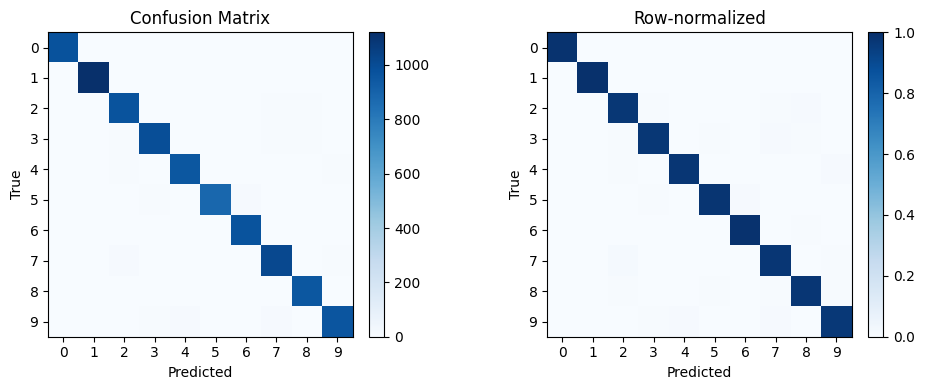

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


y_pred = best.predict(X_te)   

cm = confusion_matrix(y_te, y_pred)
print("Confusion matrix (counts):")
print(cm)


cm_row = confusion_matrix(y_te, y_pred, normalize="true")
print("\nConfusion matrix (row-normalized):")
print(np.round(cm_row, 3)) 


fig, axes = plt.subplots(1, 2, figsize=(10, 4))


im0 = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticks(range(10)); axes[0].set_yticks(range(10))
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)


im1 = axes[1].imshow(cm_row, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Row-normalized")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [17]:
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=10000, stratify=y, random_state=0
)


pipe = Pipeline([
    ("spc", SPCSelectorTau(tau=0.02, fallback_k=500)),
    ("pca", PCA(whiten=False, svd_solver="randomized", random_state=0)),  
    ("clf", LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000))
])


param_grid = {
    "spc__tau": [0.05],
    "pca__n_components": [150],    
    "clf__C": [2.0]
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("CV best acc:", gs.best_score_)

best = gs.best_estimator_
pred = best.predict(X_te)
print("Test acc:", accuracy_score(y_te, pred))
print(classification_report(y_te, pred))

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'clf__C': 2.0, 'pca__n_components': 150, 'spc__tau': 0.05}
CV best acc: 0.8511833333333333
Test acc: 0.8536
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1000
           1       0.97      0.96      0.96      1000
           2       0.77      0.74      0.75      1000
           3       0.84      0.90      0.86      1000
           4       0.73      0.77      0.75      1000
           5       0.94      0.94      0.94      1000
           6       0.65      0.60      0.63      1000
           7       0.92      0.94      0.93      1000
           8       0.95      0.94      0.95      1000
           9       0.94      0.94      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion matrix (counts):
[[820   2  22  50   4   1  90   1  10   0]
 [  3 960   6  24   2   0   4   0   0   1]
 [ 11   3 738  10 151   0  81   0   6   0]
 [ 32  12   4 895  26   0  26   0   4   1]
 [  1   4  85  39 767   0 102   0   2   0]
 [  1   0   0   0   0 937   0  37   4  21]
 [134   5 104  40  98   0 601   0  18   0]
 [  0   0   0   0   0  24   0 942   0  34]
 [  4   4   5  12   1  12  17   7 937   1]
 [  0   0   0   0   0  22   1  37   1 939]]

Confusion matrix (row-normalized):
[[0.82  0.002 0.022 0.05  0.004 0.001 0.09  0.001 0.01  0.   ]
 [0.003 0.96  0.006 0.024 0.002 0.    0.004 0.    0.    0.001]
 [0.011 0.003 0.738 0.01  0.151 0.    0.081 0.    0.006 0.   ]
 [0.032 0.012 0.004 0.895 0.026 0.    0.026 0.    0.004 0.001]
 [0.001 0.004 0.085 0.039 0.767 0.    0.102 0.    0.002 0.   ]
 [0.001 0.    0.    0.    0.    0.937 0.    0.037 0.004 0.021]
 [0.134 0.005 0.104 0.04  0.098 0.    0.601 0.    0.018 0.   ]
 [0.    0.    0.    0.    0.    0.024 0.    0.942 0.    0.034]
 [

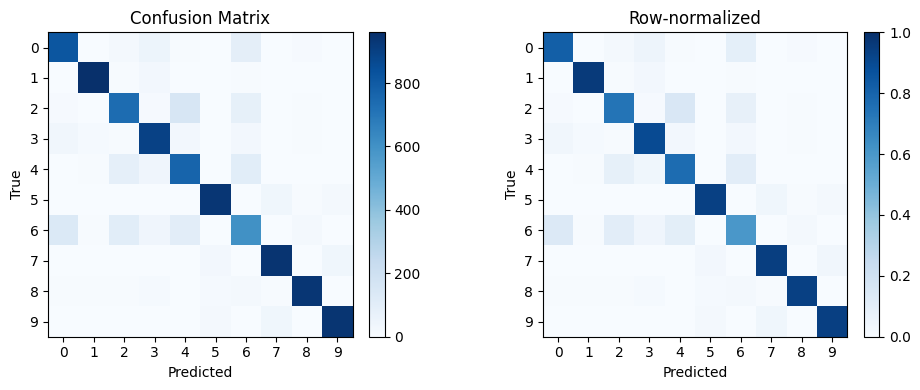

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


y_pred = best.predict(X_te)   

cm = confusion_matrix(y_te, y_pred)
print("Confusion matrix (counts):")
print(cm)


cm_row = confusion_matrix(y_te, y_pred, normalize="true")
print("\nConfusion matrix (row-normalized):")
print(np.round(cm_row, 3))  


fig, axes = plt.subplots(1, 2, figsize=(10, 4))


im0 = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticks(range(10)); axes[0].set_yticks(range(10))
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)


im1 = axes[1].imshow(cm_row, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Row-normalized")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [19]:
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=10000, stratify=y, random_state=0
)


pipe = Pipeline([
    ("spc", SPCSelectorTau(tau=0.02, fallback_k=500)),
    ("pca", PCA(whiten=False, svd_solver="randomized", random_state=0)),  
    ("clf", SVC(kernel="rbf"))
])


param_grid = {
    "spc__tau": [0.05],
    "pca__n_components": [150],    
    "clf__C": [2.0]
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("CV best acc:", gs.best_score_)

best = gs.best_estimator_
pred = best.predict(X_te)
print("Test acc:", accuracy_score(y_te, pred))
print(classification_report(y_te, pred))


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best params: {'clf__C': 2.0, 'pca__n_components': 150, 'spc__tau': 0.05}
CV best acc: 0.8913833333333333
Test acc: 0.8992
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1000
           1       0.99      0.97      0.98      1000
           2       0.84      0.81      0.83      1000
           3       0.88      0.93      0.91      1000
           4       0.80      0.85      0.82      1000
           5       0.97      0.96      0.97      1000
           6       0.77      0.71      0.74      1000
           7       0.94      0.96      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.96      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



Confusion matrix (counts):
[[820   2  22  50   4   1  90   1  10   0]
 [  3 960   6  24   2   0   4   0   0   1]
 [ 11   3 738  10 151   0  81   0   6   0]
 [ 32  12   4 895  26   0  26   0   4   1]
 [  1   4  85  39 767   0 102   0   2   0]
 [  1   0   0   0   0 937   0  37   4  21]
 [134   5 104  40  98   0 601   0  18   0]
 [  0   0   0   0   0  24   0 942   0  34]
 [  4   4   5  12   1  12  17   7 937   1]
 [  0   0   0   0   0  22   1  37   1 939]]

Confusion matrix (row-normalized):
[[0.82  0.002 0.022 0.05  0.004 0.001 0.09  0.001 0.01  0.   ]
 [0.003 0.96  0.006 0.024 0.002 0.    0.004 0.    0.    0.001]
 [0.011 0.003 0.738 0.01  0.151 0.    0.081 0.    0.006 0.   ]
 [0.032 0.012 0.004 0.895 0.026 0.    0.026 0.    0.004 0.001]
 [0.001 0.004 0.085 0.039 0.767 0.    0.102 0.    0.002 0.   ]
 [0.001 0.    0.    0.    0.    0.937 0.    0.037 0.004 0.021]
 [0.134 0.005 0.104 0.04  0.098 0.    0.601 0.    0.018 0.   ]
 [0.    0.    0.    0.    0.    0.024 0.    0.942 0.    0.034]
 [

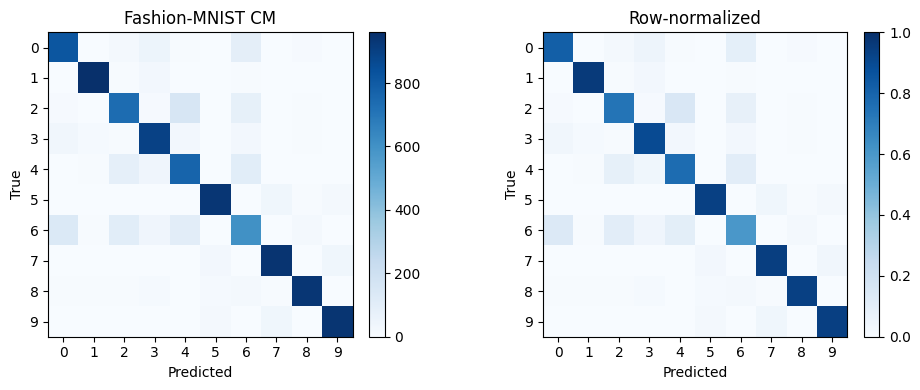

In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te, y_pred)
print("Confusion matrix (counts):")
print(cm)


cm_row = confusion_matrix(y_te, y_pred, normalize="true")
print("\nConfusion matrix (row-normalized):")
print(np.round(cm_row, 3))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))


im0 = ax[0].imshow(cm, cmap="Blues")
ax[0].set_title("Fashion-MNIST CM")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")
ax[0].set_xticks(range(10)); ax[0].set_yticks(range(10))
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)


im1 = ax[1].imshow(cm_row, cmap="Blues", vmin=0, vmax=1)
ax[1].set_title("Row-normalized")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")
ax[1].set_xticks(range(10)); ax[1].set_yticks(range(10))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

SEED = 0

real_names = np.array([
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
])


X, y = fetch_openml("CIFAR_10", version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=10000, stratify=y, random_state=0
)


pipe = Pipeline([
    ("spc", SPCSelectorTau(tau=0.02, fallback_k=500)),
    ("pca", PCA(whiten=False, svd_solver="randomized", random_state=0)),  
    ("clf", LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000))
])


param_grid = {
    "spc__tau": [0.05],
    "pca__n_components": [500],    
    "clf__C": [2.0]
}
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=0)
gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("CV best acc:", gs.best_score_)

best = gs.best_estimator_

sel = best.named_steps["spc"]
n_selected = sel.keep_idx_.size
print(f"[SPC] tau={sel.tau}  ->  selected features: {n_selected} / {X.shape[1]} "f"({n_selected / X.shape[1]:.1%})")



Fitting 2 folds for each of 1 candidates, totalling 2 fits


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'clf__C': 2.0, 'pca__n_components': 500, 'spc__tau': 0.05}
CV best acc: 0.39083999999999997
[SPC] tau=0.05  ->  selected features: 3060 / 3072 (99.6%)


In [23]:
pred = best.predict(X_te)
print("Test acc:", accuracy_score(y_te, pred))
print(classification_report(y_te, pred))

Test acc: 0.4091
              precision    recall  f1-score   support

           0       0.45      0.48      0.47      1000
           1       0.44      0.50      0.47      1000
           2       0.30      0.26      0.28      1000
           3       0.29      0.25      0.27      1000
           4       0.39      0.33      0.36      1000
           5       0.35      0.34      0.34      1000
           6       0.40      0.47      0.43      1000
           7       0.46      0.45      0.45      1000
           8       0.50      0.54      0.52      1000
           9       0.45      0.48      0.47      1000

    accuracy                           0.41     10000
   macro avg       0.40      0.41      0.41     10000
weighted avg       0.40      0.41      0.41     10000



In [24]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import SelectKBest, f_classif

SEED = 0


X, y = fetch_openml("CIFAR_10", version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
_, y = np.unique(y, return_inverse=True)  


X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=10000, stratify=y, random_state=SEED
)




pipe = Pipeline([
    ("spc", SPCSelectorTau(tau=0.02, fallback_k=500)),
    ("pca", PCA(whiten=False, svd_solver="randomized", random_state=0)), 
    ("clf", SVC(kernel="rbf"))
])


param_grid = {
    "spc__tau": [0.05],
    "pca__n_components": [500],    
    "clf__C": [2.0]
}
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=0)
gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("CV best acc:", gs.best_score_)

best = gs.best_estimator_
pred = best.predict(X_te)
print("Test acc:", accuracy_score(y_te, pred))

print(classification_report(
    y_te, pred,
    target_names=[
        "airplane","automobile","bird","cat","deer",
        "dog","frog","horse","ship","truck"
    ]
))



Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best params: {'clf__C': 2.0, 'pca__n_components': 500, 'spc__tau': 0.05}
CV best acc: 0.52868
Test acc: 0.5664
              precision    recall  f1-score   support

    airplane       0.60      0.64      0.62      1000
  automobile       0.67      0.69      0.68      1000
        bird       0.43      0.43      0.43      1000
         cat       0.40      0.41      0.40      1000
        deer       0.50      0.49      0.50      1000
         dog       0.50      0.43      0.46      1000
        frog       0.58      0.62      0.60      1000
       horse       0.65      0.60      0.62      1000
        ship       0.69      0.69      0.69      1000
       truck       0.64      0.66      0.65      1000

    accuracy                           0.57     10000
   macro avg       0.57      0.57      0.57     10000
weighted avg       0.57      0.57      0.57     10000



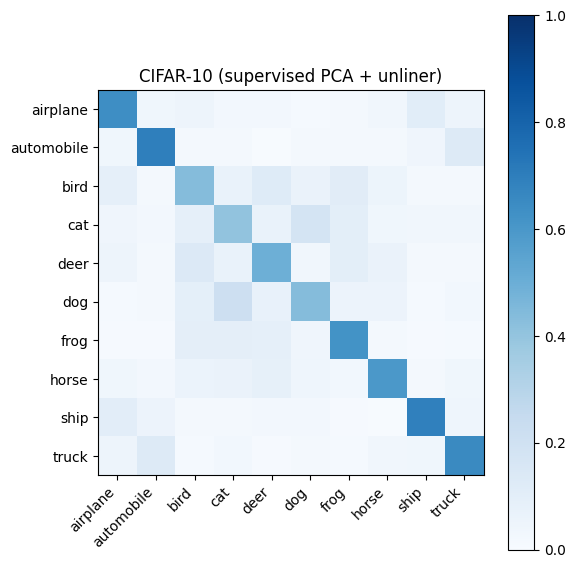

In [25]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
real_names = np.array([
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
])
cm = confusion_matrix(y_te,pred, normalize="true")
plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(10), real_names, rotation=45, ha="right")
plt.yticks(range(10), real_names)
plt.title("CIFAR-10 (supervised PCA + unliner)")
plt.colorbar()
plt.tight_layout()
plt.show()


SAE MODEL

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
import sys
import numpy as np
import os

torch.manual_seed(1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((.5, .5, .5), (.5, .5, .5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=True)


class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32,kernel_size=(3, 3), stride=(1, 1))
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,kernel_size=(3, 3), stride=(1, 1))
        self.fc1_2 = nn.Linear(in_features=50176, out_features=256)
        self.fc2_3 = nn.Linear(in_features=256, out_features=32)
        self.fc3_2 = nn.Linear(in_features=32, out_features=256)
        self.fc2_1 = nn.Linear(in_features=256, out_features=50176)
        self.conv3 = nn.ConvTranspose2d(in_channels=64, out_channels=64,
                                        kernel_size=(3, 3), stride=(1, 1))
        self.conv4 = nn.ConvTranspose2d(in_channels=64, out_channels=3,
                                        kernel_size=(3, 3), stride=(1, 1))

        self.softmax = nn.Linear(in_features=32, out_features=10)

    def forward(self, x):
        xe = F.relu(self.conv1(x))
        xe = F.relu(self.conv2(xe))
        shp = [xe.shape[0], xe.shape[1], xe.shape[2], xe.shape[3]]
        xe = xe.view(-1, shp[1] * shp[2] * shp[3])
        xe = F.relu(self.fc1_2(xe))
        xe = F.relu(self.fc2_3(xe))

        xd = F.relu(self.fc3_2(xe))
        xd = F.relu(self.fc2_1(xd))
        xd = torch.reshape(xd, (shp[0], shp[1], shp[2], shp[3]))
        xd = F.relu(self.conv3(xd))
        x_hat = F.relu(self.conv4(xd))

        y_hat = self.softmax(xe)

        return x_hat, y_hat

    def name(self):
        return 'lenet'


def train(weight):
    path = './models/pytorch/'
    os.makedirs(path, exist_ok=True)  

    filename = '20epochs-wr' + str(weight) + '-arch5'
    wp = 1
    wr = weight
    load_model = False
    init_epoch = 0
    history = []

    net = ConvNet().to(device)  

    classificationLoss = nn.CrossEntropyLoss()
    reconstructionLoss = nn.L1Loss()
    optimizer = optim.SGD(net.parameters(), lr=.01, momentum=.9)

    if load_model:
        checkpoint = torch.load(path + filename + ".ckp", map_location=device)
        net.load_state_dict(checkpoint[0]['model_state_dict'])
        optimizer.load_state_dict(checkpoint[0]['optimizer_state_dict'])
        init_epoch = checkpoint[0]['epoch'] + 1
        history = (np.load(path + filename + '-history.npy', history)).tolist()

    for epoch in range(init_epoch, 7, 1):
        # train
        running_loss = 0.0
        model_acc = 0.0
        total_images = 0

        net.train()
        for i, data in enumerate(trainloader, 0):
            
            inputs, labels = data[0].to(device), data[1].to(device)

            optimizer.zero_grad()

            x_hat, y_hat = net(inputs)

            loss = wp * classificationLoss(y_hat, labels) + wr * reconstructionLoss(x_hat, inputs)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(y_hat.data, 1)
            total_images += labels.size(0)
            num_correct = (predicted == labels).sum().item()
            model_acc += num_correct / (len(trainloader) * inputs.size(0))
            running_loss += loss.item() / len(trainloader)

        print("Epoch: ", epoch," - model_loss: " + str(running_loss) + ' - train_acc: ' + str(model_acc))

        # test
        net.eval()
        with torch.no_grad():
            test_acc = 0.0
            total_images = 0.0
            for data in testloader:
                images, labels = data[0].to(device), data[1].to(device)
                x_hat, y_hat = net(images)
                _, predicted = torch.max(y_hat.data, 1)
                total_images += labels.size(0)
                test_acc += (predicted == labels).sum().item() / (len(testloader) * images.size(0))
            print('Model Test accuracy:', test_acc)

        history.append([model_acc, test_acc])

        # store model（state_dict ）
        checkpoint = ({
            'epoch': epoch,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        },)
        torch.save(checkpoint, path + filename + '.ckp')
        torch.save(net, path + filename + '.mdl')

    np.save(path + filename + '-history.npy', history)


train(0.1)


Using device: cpu
Epoch:  0  - model_loss: 1.6449107626819852 - train_acc: 0.416040601023017
Model Test accuracy: 0.5370222929936305
Epoch:  1  - model_loss: 1.2173044271481321 - train_acc: 0.5799632352941169
Model Test accuracy: 0.6095740445859873
Epoch:  2  - model_loss: 0.9705979074053736 - train_acc: 0.669237531969311
Model Test accuracy: 0.6409235668789807
Epoch:  3  - model_loss: 0.734571933327124 - train_acc: 0.7570532289002574
Model Test accuracy: 0.6616242038216555
Epoch:  4  - model_loss: 0.5002471162458824 - train_acc: 0.8404531649616392
Model Test accuracy: 0.6478901273885347
Epoch:  5  - model_loss: 0.2998614203842242 - train_acc: 0.9111652813299261
Model Test accuracy: 0.6536624203821653
Epoch:  6  - model_loss: 0.21597582331436974 - train_acc: 0.9395380434782638
Model Test accuracy: 0.6632165605095547


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import os

torch.manual_seed(1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  
])

trainset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)



class ConvNetMNIST(nn.Module):
    def __init__(self):
        super(ConvNetMNIST, self).__init__()
        # Encoder：input 1x28x28
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)   # 16x28x28
        self.pool1 = nn.MaxPool2d(2, 2)                                     # 16x14x14

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)  # 32x14x14
        self.pool2 = nn.MaxPool2d(2, 2)                                     # 32x7x7

        # 32 * 7 * 7 = 1568
        self.fc_enc1 = nn.Linear(1568, 128)
        self.fc_enc2 = nn.Linear(128, 32)   # latent 32 

        
        self.fc_dec1 = nn.Linear(32, 128)
        self.fc_dec2 = nn.Linear(128, 1568)

        self.deconv1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)  # 16x14x14
        self.deconv2 = nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2)   # 1x28x28

        
        self.classifier = nn.Linear(32, 10)

    def forward(self, x):
        # Encoder
        z = F.relu(self.conv1(x))
        z = self.pool1(z)
        z = F.relu(self.conv2(z))
        z = self.pool2(z)   # [B, 32, 7, 7]

        batch_size = z.size(0)
        z = z.view(batch_size, -1)  # [B, 1568]
        z = F.relu(self.fc_enc1(z))
        z_latent = F.relu(self.fc_enc2(z))  # 32 

        # Decoder
        d = F.relu(self.fc_dec1(z_latent))
        d = F.relu(self.fc_dec2(d))
        d = d.view(batch_size, 32, 7, 7)
        d = F.relu(self.deconv1(d))
        x_hat = torch.tanh(self.deconv2(d))   

        # classifier
        y_hat = self.classifier(z_latent)

        return x_hat, y_hat

    def name(self):
        return "mnist_sae"



def train(weight, num_epochs=7):
    
    path = './models_mnist/'
    os.makedirs(path, exist_ok=True)

    filename = f'mnist-wr{weight}-epochs{num_epochs}'
    wp = 1.0     
    wr = weight  

    net = ConvNetMNIST().to(device)
    classificationLoss = nn.CrossEntropyLoss()
    reconstructionLoss = nn.MSELoss()  

    optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

    history = []

    for epoch in range(num_epochs):
        # ---------- Train ----------
        net.train()
        running_loss = 0.0
        train_acc = 0.0
        total_images = 0

        for i, (inputs, labels) in enumerate(trainloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            x_hat, y_hat = net(inputs)

            loss_cls = classificationLoss(y_hat, labels)
            loss_rec = reconstructionLoss(x_hat, inputs)
            loss = wp * loss_cls + wr * loss_rec

            loss.backward()
            optimizer.step()

            _, predicted = torch.max(y_hat.data, 1)
            batch_size = labels.size(0)
            total_images += batch_size
            num_correct = (predicted == labels).sum().item()
            train_acc += num_correct

            running_loss += loss.item()

        train_acc = train_acc / total_images
        running_loss = running_loss / len(trainloader)

        # ---------- Test ----------
        net.eval()
        test_acc = 0.0
        total_test = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                x_hat, y_hat = net(inputs)
                _, predicted = torch.max(y_hat.data, 1)
                total_test += labels.size(0)
                test_acc += (predicted == labels).sum().item()

        test_acc = test_acc / total_test

        print(f"Epoch {epoch+1}/{num_epochs} "
              f"- loss: {running_loss:.4f} "
              f"- train_acc: {train_acc:.4f} "
              f"- test_acc: {test_acc:.4f}")

        history.append([train_acc, test_acc])

        checkpoint = ({
            'epoch': epoch,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        },)
        torch.save(checkpoint, os.path.join(path, filename + '.ckp'))
        torch.save(net, os.path.join(path, filename + '.mdl'))

    np.save(os.path.join(path, filename + '-history.npy'), history)



if __name__ == "__main__":
    
    w = 0.1
    train(weight=w, num_epochs=7)


Using device: cpu


100.0%
100.0%
100.0%
100.0%


Epoch 1/7 - loss: 0.4786 - train_acc: 0.8593 - test_acc: 0.9770
Epoch 2/7 - loss: 0.0988 - train_acc: 0.9805 - test_acc: 0.9829
Epoch 3/7 - loss: 0.0731 - train_acc: 0.9863 - test_acc: 0.9882
Epoch 4/7 - loss: 0.0593 - train_acc: 0.9894 - test_acc: 0.9882
Epoch 5/7 - loss: 0.0507 - train_acc: 0.9915 - test_acc: 0.9892
Epoch 6/7 - loss: 0.0451 - train_acc: 0.9929 - test_acc: 0.9879
Epoch 7/7 - loss: 0.0396 - train_acc: 0.9941 - test_acc: 0.9918


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import os

torch.manual_seed(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  
])

trainset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)



class ConvNetFMNIST(nn.Module):
    def __init__(self):
        super(ConvNetFMNIST, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)   # 16x28x28
        self.pool1 = nn.MaxPool2d(2, 2)                                     # 16x14x14

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)  # 32x14x14
        self.pool2 = nn.MaxPool2d(2, 2)                                     # 32x7x7

        # 32 * 7 * 7 = 1568
        self.fc_enc1 = nn.Linear(1568, 128)
        self.fc_enc2 = nn.Linear(128, 32)   # latent 32 维

        # Decoder：
        self.fc_dec1 = nn.Linear(32, 128)
        self.fc_dec2 = nn.Linear(128, 1568)

        self.deconv1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)  # 16x14x14
        self.deconv2 = nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2)   # 1x28x28

        #  
        self.classifier = nn.Linear(32, 10)

    def forward(self, x):
        # Encoder
        z = F.relu(self.conv1(x))
        z = self.pool1(z)
        z = F.relu(self.conv2(z))
        z = self.pool2(z)   # [B, 32, 7, 7]

        batch_size = z.size(0)
        z = z.view(batch_size, -1)  # [B, 1568]
        z = F.relu(self.fc_enc1(z))
        z_latent = F.relu(self.fc_enc2(z))  # 32 D

        # Decoder
        d = F.relu(self.fc_dec1(z_latent))
        d = F.relu(self.fc_dec2(d))
        d = d.view(batch_size, 32, 7, 7)
        d = F.relu(self.deconv1(d))
        x_hat = torch.tanh(self.deconv2(d))   # output [-1,1]

    
        y_hat = self.classifier(z_latent)

        return x_hat, y_hat

    def name(self):
        return "fashion_mnist_sae"




def train(weight, num_epochs=7):
    
    path = './models_fashion_mnist/'
    os.makedirs(path, exist_ok=True)

    filename = f'fashionmnist-wr{weight}-epochs{num_epochs}'
    wp = 1.0     # classification loss 
    wr = weight  # reconstruction loss 

    net = ConvNetFMNIST().to(device)
    classificationLoss = nn.CrossEntropyLoss()
    reconstructionLoss = nn.MSELoss()  

    optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

    history = []

    for epoch in range(num_epochs):
        # ---------- Train ----------
        net.train()
        running_loss = 0.0
        train_correct = 0
        total_images = 0

        for i, (inputs, labels) in enumerate(trainloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            x_hat, y_hat = net(inputs)

            loss_cls = classificationLoss(y_hat, labels)
            loss_rec = reconstructionLoss(x_hat, inputs)
            loss = wp * loss_cls + wr * loss_rec

            loss.backward()
            optimizer.step()

            _, predicted = torch.max(y_hat.data, 1)
            batch_size = labels.size(0)
            total_images += batch_size
            train_correct += (predicted == labels).sum().item()
            running_loss += loss.item()

        train_acc = train_correct / total_images
        running_loss = running_loss / len(trainloader)

        # ---------- Test ----------
        net.eval()
        test_correct = 0
        total_test = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                x_hat, y_hat = net(inputs)
                _, predicted = torch.max(y_hat.data, 1)
                total_test += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_acc = test_correct / total_test

        print(f"Epoch {epoch+1}/{num_epochs} "
              f"- loss: {running_loss:.4f} "
              f"- train_acc: {train_acc:.4f} "
              f"- test_acc: {test_acc:.4f}")

        history.append([train_acc, test_acc])


        checkpoint = ({
            'epoch': epoch,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        },)
        torch.save(checkpoint, os.path.join(path, filename + '.ckp'))
        torch.save(net, os.path.join(path, filename + '.mdl'))

    np.save(os.path.join(path, filename + '-history.npy'), history)



if __name__ == "__main__":
    w = 0.1          
    train(weight=w, num_epochs=7)


0.4%

Using device: cpu


100.0%
100.0%
100.0%
100.0%


Epoch 1/7 - loss: 0.7722 - train_acc: 0.7374 - test_acc: 0.8511
Epoch 2/7 - loss: 0.3989 - train_acc: 0.8705 - test_acc: 0.8783
Epoch 3/7 - loss: 0.3341 - train_acc: 0.8901 - test_acc: 0.8862
Epoch 4/7 - loss: 0.2950 - train_acc: 0.9011 - test_acc: 0.8902
Epoch 5/7 - loss: 0.2648 - train_acc: 0.9109 - test_acc: 0.9012
Epoch 6/7 - loss: 0.2442 - train_acc: 0.9179 - test_acc: 0.9089
Epoch 7/7 - loss: 0.2265 - train_acc: 0.9238 - test_acc: 0.9060


: 

In [ ]:
# mnist_direct_pca.py
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

def run_mnist_direct_pca(random_state=0, test_size=10000, whiten=True):
    # load dataset
    X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
    X = X.astype(np.float32) / 255.0
    y = y.astype(np.int64)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # PCA → Softmax LR 
    pipe = Pipeline(steps=[
        ("pca", PCA(whiten=whiten, svd_solver="randomized", random_state=random_state)),
        ("clf", LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=2000))
    ])

    #  d and  C
    param_grid = {
        "pca__n_components": [50, 80, 100, 150, 200],
        "clf__C": [1.0, 2.0, 5.0],
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
    gs.fit(X_tr, y_tr)

    print("Best params:", gs.best_params_)
    print("CV best acc:", f"{gs.best_score_:.4f}")


    best = gs.best_estimator_
    y_pred = best.predict(X_te)
    test_acc = accuracy_score(y_te, y_pred)
    print("Test acc:", f"{test_acc:.4f}")
    print(classification_report(y_te, y_pred, digits=4))

    cm = confusion_matrix(y_te, y_pred, normalize="true")
    np.set_printoptions(precision=3, suppress=True)
    print("Row-normalized confusion matrix:\n", cm)

    pca = best.named_steps["pca"]
    m = pca.n_components_
    cum_evr = float(pca.explained_variance_ratio_.cumsum()[-1])
    print(f"PCA n_components = {m}, cumulative explained variance = {cum_evr:.3f}")

    return {
        "best_params": gs.best_params_,
        "cv_best_acc": gs.best_score_,
        "test_acc": test_acc,
        "cm": cm,
        "pca_m": m,
        "cum_evr": cum_evr,
    }

if __name__ == "__main__":
    run_mnist_direct_pca(random_state=0, test_size=10000, whiten=True)


Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'clf__C': 2.0, 'pca__n_components': 200}
CV best acc: 0.9184
Test acc: 0.9239
              precision    recall  f1-score   support

           0     0.9625    0.9635    0.9630       986
           1     0.9492    0.9796    0.9641      1125
           2     0.9210    0.9099    0.9154       999
           3     0.9143    0.8892    0.9016      1020
           4     0.9171    0.9303    0.9236       975
           5     0.9070    0.8758    0.8911       902
           6     0.9384    0.9623    0.9502       982
           7     0.9483    0.9328    0.9405      1042
           8     0.8825    0.8779    0.8802       975
           9     0.8912    0.9064    0.8988       994

    accuracy                         0.9239     10000
   macro avg     0.9231    0.9228    0.9229     10000
weighted avg     0.9238    0.9239    0.9237     10000

Row-normalized confusion matrix:
 [[0.963 0.    0.002 0.005 0.004 0.009 0.006 0.002 0.007 0.001]
 [0.    0.98  0.003 0.002 0.    0.002 0.001 0.002 0.

In [ ]:
# mnist_direct_pca.py
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

def run_mnist_direct_pca(random_state=0, test_size=10000, whiten=True):
    # load dataset
    X, y = fetch_openml("Fashion-MNIST", version=1, return_X_y=True, as_frame=False)
    X = X.astype(np.float32) / 255.0
    y = y.astype(np.int64)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # PCA → Softmax LR 
    pipe = Pipeline(steps=[
        ("pca", PCA(whiten=whiten, svd_solver="randomized", random_state=random_state)),
        ("clf", LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=2000))
    ])

    #  d and  C
    param_grid = {
        "pca__n_components": [50, 80, 100, 150, 200],
        "clf__C": [1.0, 2.0, 5.0],
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
    gs.fit(X_tr, y_tr)

    print("Best params:", gs.best_params_)
    print("CV best acc:", f"{gs.best_score_:.4f}")


    best = gs.best_estimator_
    y_pred = best.predict(X_te)
    test_acc = accuracy_score(y_te, y_pred)
    print("Test acc:", f"{test_acc:.4f}")
    print(classification_report(y_te, y_pred, digits=4))

    # confusion matrix
    cm = confusion_matrix(y_te, y_pred, normalize="true")
    np.set_printoptions(precision=3, suppress=True)
    print("Row-normalized confusion matrix:\n", cm)

    #print PCA information
    pca = best.named_steps["pca"]
    m = pca.n_components_
    cum_evr = float(pca.explained_variance_ratio_.cumsum()[-1])
    print(f"PCA n_components = {m}, cumulative explained variance = {cum_evr:.3f}")

    return {
        "best_params": gs.best_params_,
        "cv_best_acc": gs.best_score_,
        "test_acc": test_acc,
        "cm": cm,
        "pca_m": m,
        "cum_evr": cum_evr,
    }

if __name__ == "__main__":
    run_mnist_direct_pca(random_state=0, test_size=10000, whiten=True)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'clf__C': 2.0, 'pca__n_components': 150}
CV best acc: 0.8522
Test acc: 0.8520
              precision    recall  f1-score   support

           0     0.8134    0.8110    0.8122      1000
           1     0.9756    0.9580    0.9667      1000
           2     0.7590    0.7340    0.7463      1000
           3     0.8346    0.8880    0.8605      1000
           4     0.7288    0.7740    0.7507      1000
           5     0.9335    0.9400    0.9367      1000
           6     0.6480    0.6020    0.6242      1000
           7     0.9228    0.9320    0.9274      1000
           8     0.9524    0.9400    0.9461      1000
           9     0.9457    0.9410    0.9434      1000

    accuracy                         0.8520     10000
   macro avg     0.8514    0.8520    0.8514     10000
weighted avg     0.8514    0.8520    0.8514     10000

Row-normalized confusion matrix:
 [[0.811 0.003 0.022 0.049 0.003 0.004 0.097 0.001 0.009 0.001]
 [0.005 0.958 0.007 0.023 0.002 0.    0.004 0.    0.

In [1]:
# mnist_direct_pca.py
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

def run_mnist_direct_pca(random_state=0, test_size=10000, whiten=True):
    # load dataset
    X, y = fetch_openml("CIFAR_10", version=1, return_X_y=True, as_frame=False)
    X = X.astype(np.float32) / 255.0
    y = y.astype(np.int64)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # PCA → Softmax LR 
    pipe = Pipeline(steps=[
        ("pca", PCA(whiten=whiten, svd_solver="randomized", random_state=random_state)),
        ("clf", LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=2000))
    ])

    #  d and  C
    param_grid = {
        "pca__n_components": [150, 200,500],
        "clf__C": [1.0, 2.0, 5.0],
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
    gs.fit(X_tr, y_tr)

    print("Best params:", gs.best_params_)
    print("CV best acc:", f"{gs.best_score_:.4f}")

    
    best = gs.best_estimator_
    y_pred = best.predict(X_te)
    test_acc = accuracy_score(y_te, y_pred)
    print("Test acc:", f"{test_acc:.4f}")
    print(classification_report(y_te, y_pred, digits=4))

    
    cm = confusion_matrix(y_te, y_pred, normalize="true")
    np.set_printoptions(precision=3, suppress=True)
    print("Row-normalized confusion matrix:\n", cm)


    pca = best.named_steps["pca"]
    m = pca.n_components_
    cum_evr = float(pca.explained_variance_ratio_.cumsum()[-1])
    print(f"PCA n_components = {m}, cumulative explained variance = {cum_evr:.3f}")

    return {
        "best_params": gs.best_params_,
        "cv_best_acc": gs.best_score_,
        "test_acc": test_acc,
        "cm": cm,
        "pca_m": m,
        "cum_evr": cum_evr,
    }

if __name__ == "__main__":
    run_mnist_direct_pca(random_state=0, test_size=10000, whiten=True)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'clf__C': 1.0, 'pca__n_components': 200}
CV best acc: 0.4068
Test acc: 0.4063
              precision    recall  f1-score   support

           0     0.4525    0.4910    0.4710      1000
           1     0.4345    0.4780    0.4552      1000
           2     0.3191    0.2540    0.2829      1000
           3     0.2877    0.2630    0.2748      1000
           4     0.3631    0.3010    0.3291      1000
           5     0.3431    0.3290    0.3359      1000
           6     0.4002    0.4830    0.4377      1000
           7     0.4525    0.4430    0.4477      1000
           8     0.4948    0.5220    0.5080      1000
           9     0.4638    0.4990    0.4807      1000

    accuracy                         0.4063     10000
   macro avg     0.4011    0.4063    0.4023     10000
weighted avg     0.4011    0.4063    0.4023     10000

Row-normalized confusion matrix:
 [[0.491 0.069 0.042 0.041 0.02  0.019 0.027 0.069 0.155 0.067]
 [0.053 0.478 0.026 0.031 0.033 0.037 0.042 0.057 0.

Wrong direction


Step 1: 正在训练基础 SAE...
Step 2: 对瓶颈层进行 PCA 二筛...
维度 2: 准确率=0.6240, 重构误差(MSE)=0.2867
维度 4: 准确率=0.9000, 重构误差(MSE)=0.2526
维度 8: 准确率=0.9735, 重构误差(MSE)=0.2097
维度 16: 准确率=0.9778, 重构误差(MSE)=0.1219
维度 32: 准确率=0.9783, 重构误差(MSE)=0.0749


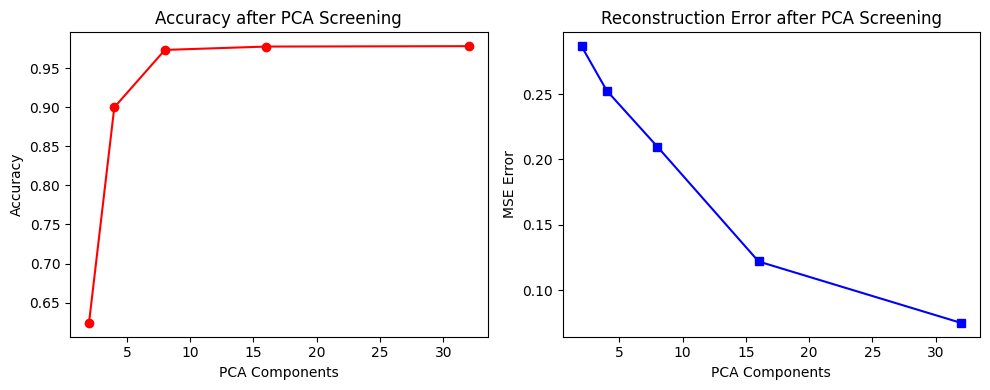

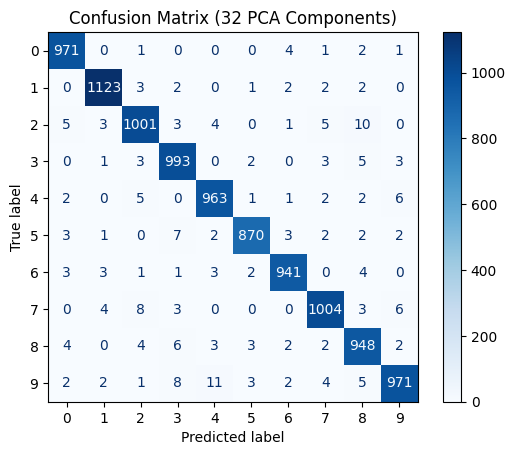

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 64  # SAE bottleneck original D

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

# --- 2. SAE model ---
class MNIST_SAE(nn.Module):
    def __init__(self, latent_dim):
        super(MNIST_SAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 512), nn.ReLU(), nn.Linear(512, latent_dim)
        )
        self.classifier = nn.Linear(latent_dim, 10)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512), nn.ReLU(), nn.Linear(512, 784), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x.view(x.size(0), -1))
        return self.decoder(z), self.classifier(z), z

# --- 3. train SAE ---
print("Step 1: train SAE...")
model = MNIST_SAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        rec, cls, _ = model(imgs)
        loss = nn.CrossEntropyLoss()(cls, lbls) + 0.1 * nn.MSELoss()(rec, imgs.view(imgs.size(0), -1))
        loss.backward(); optimizer.step()

# --- 4. PCA select and verify ---
def get_data(loader):
    model.eval()
    zs, ys, imgs_raw = [], [], []
    with torch.no_grad():
        for img, lbl in loader:
            _, _, z = model(img.to(device))
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
            imgs_raw.append(img.view(img.size(0), -1).numpy())
    return np.vstack(zs), np.hstack(ys), np.vstack(imgs_raw)

Z_train, Y_train, X_train_raw = get_data(train_loader)
Z_test, Y_test, X_test_raw = get_data(test_loader)

dims = [2, 4, 8, 16, 32]
accuracies = []
reconstruction_errors = []

print("Step 2: use PCA on bottleneck...")
for d in dims:
    # PCA select
    pca = PCA(n_components=d)
    Z_train_pca = pca.fit_transform(Z_train)
    Z_test_pca = pca.transform(Z_test)
    
    # 1. classfier
    from sklearn.linear_model import LogisticRegression
    clf = LogisticRegression(max_iter=500).fit(Z_train_pca, Y_train)
    acc = clf.score(Z_test_pca, Y_test)
    accuracies.append(acc)
    
    # 2. reconstruction
    Z_reconstructed = pca.inverse_transform(Z_test_pca)
    Z_reconstructed_torch = torch.tensor(Z_reconstructed).to(device)
    with torch.no_grad():
        X_rec = model.decoder(Z_reconstructed_torch).cpu().numpy()
    
    rec_error = np.mean((X_test_raw - X_rec)**2)
    reconstruction_errors.append(rec_error)
    print(f" {d}: acc={acc:.4f}, (MSE)={rec_error:.4f}")

# result

# Output 1: Accuracy Line Chart
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(dims, accuracies, 'o-r')
plt.title("Accuracy after PCA Screening")
plt.xlabel("PCA Components")
plt.ylabel("Accuracy")

# Output 2: Line chart of reconstruction error
plt.subplot(1, 2, 2)
plt.plot(dims, reconstruction_errors, 's-b')
plt.title("Reconstruction Error after PCA Screening")
plt.xlabel("PCA Components")
plt.ylabel("MSE Error")
plt.tight_layout()
plt.show()

# Output 3: Confusion Matrix (for 32 dimensions)
pca_32 = PCA(n_components=32)
Z_test_32 = pca_32.fit_transform(Z_test)

y_pred = LogisticRegression(max_iter=500).fit(pca_32.transform(Z_train), Y_train).predict(Z_test_32)
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix (32 PCA Components)")
plt.show()

Generating SPC mask for MNIST...


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  47  48  49  50  51  52  53  54  55  56  57  59  60  61  82  83  84
  85 111 112 113 114 140 141 142 168 169 195 196 197 223 224 251 252 280
 308 335 363 364 391 392 393 419 420 421 447 448 449 476 477 504 505 531
 532 559 560 587 615 643 644 645 670 671 672 673 698 699 700 701 702 724
 725 726 727 728 729 730 731 752 753 754 755 756 757 758 759 779 780 781
 782 783] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Epoch 1/7 - Loss: 0.4365 - Acc: 0.8691
Epoch 2/7 - Loss: 0.1016 - Acc: 0.9807
Epoch 3/7 - Loss: 0.0814 - Acc: 0.9859
Epoch 4/7 - Loss: 0.0670 - Acc: 0.9888
Epoch 5/7 - Loss: 0.0547 - Acc: 0.9914
Epoch 6/7 - Loss: 0.0479 - Acc: 0.9925
Epoch 7/7 - Loss: 0.0414 - Acc: 0.9943
Evaluating on test set...


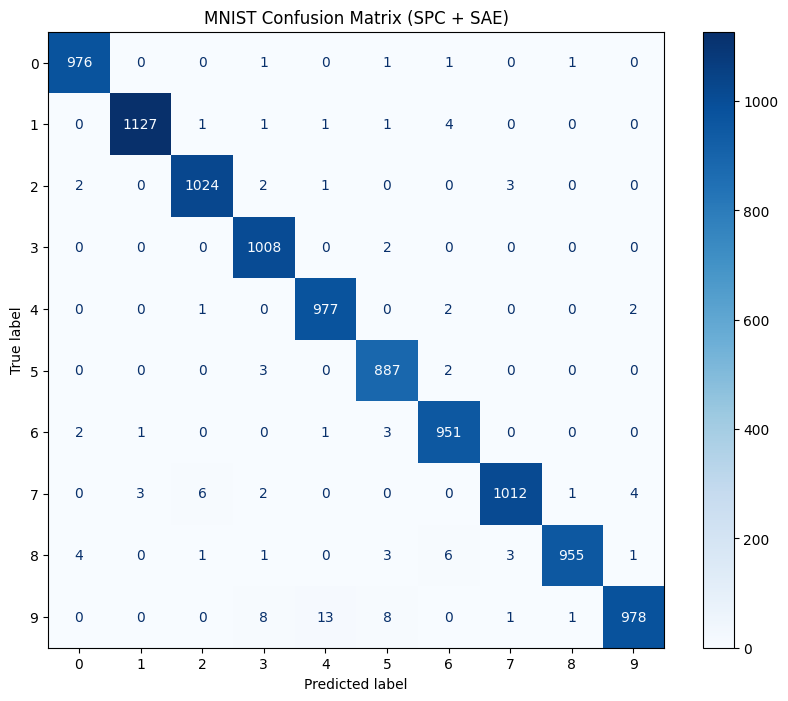

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_and_plot_cm(net, testloader, spc_mask, device):
    net.eval()
    all_preds = []
    all_labels = []
    
    print("Evaluating on test set...")
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            

            masked_inputs = inputs * spc_mask
            
            _, y_hat = net(masked_inputs)
            _, predicted = torch.max(y_hat, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    
    cm = confusion_matrix(all_labels, all_preds)
    
    
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
    plt.title("MNIST Confusion Matrix (SPC + SAE)")
    plt.show()


if __name__ == "__main__":
    trained_net, mask = train(weight=0.1, num_epochs=7, tau=0.05)
    evaluate_and_plot_cm(trained_net, testloader, mask, device)

In [47]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import os
from sklearn.feature_selection import f_classif

torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalization to [-1, 1]
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# 2. SPC 
def get_spc_mask(dataloader, tau=0.02):
    print("Generating SPC mask for MNIST...")
    X_list, y_list = [], []
    for i, (X, y) in enumerate(dataloader):
        X_list.append(X.view(X.shape[0], -1))
        y_list.append(y)
        if i > 50: break 
    X_f = torch.cat(X_list).numpy()
    y_f = torch.cat(y_list).numpy()
    f_scores, _ = f_classif(X_f, y_f)
    f_scores = np.nan_to_num(f_scores)
    mask = (f_scores >= tau * np.max(f_scores)).astype(np.float32)
    return torch.from_numpy(mask).view(1, 28, 28).to(device)

# 3. build model
class ConvNetMNIST_SAE(nn.Module):
    def __init__(self):
        super(ConvNetMNIST_SAE, self).__init__()
        # Encoder
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Bottleneck
        self.fc_enc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc_enc2 = nn.Linear(128, 32) # Latent dim = 32

        # Decoder
        self.fc_dec1 = nn.Linear(32, 128)
        self.fc_dec2 = nn.Linear(128, 1568)
        self.deconv1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.deconv2 = nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2)

        # Classifier branch
        self.classifier = nn.Linear(32, 10)

    def forward(self, x):
        batch_size = x.size(0)
        # Encoder
        z = F.relu(self.conv1(x))
        z = self.pool1(z)
        z = F.relu(self.conv2(z))
        z = self.pool2(z)
        
        z = z.view(batch_size, -1)
        z = F.relu(self.fc_enc1(z))
        z_latent = F.relu(self.fc_enc2(z))

        # Decoder
        d = F.relu(self.fc_dec1(z_latent))
        d = F.relu(self.fc_dec2(d))
        d = d.view(batch_size, 32, 7, 7)
        d = F.relu(self.deconv1(d))
        x_hat = torch.tanh(self.deconv2(d)) # output match Normalize 的 [-1, 1]

        # Classification
        y_hat = self.classifier(z_latent)
        return x_hat, y_hat

# 4. tain
def train(weight=0.1, num_epochs=7, tau=0.02):
    path = './models_mnist_sae/'
    os.makedirs(path, exist_ok=True)
    

    spc_mask = get_spc_mask(trainloader, tau=tau)
    
    net = ConvNetMNIST_SAE().to(device)
    classificationLoss = nn.CrossEntropyLoss()
    reconstructionLoss = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (inputs, labels) in enumerate(trainloader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            
            masked_inputs = inputs * spc_mask 
            
            optimizer.zero_grad()
            x_hat, y_hat = net(masked_inputs)

            loss_cls = classificationLoss(y_hat, labels)
            loss_rec = reconstructionLoss(x_hat, inputs) 
            loss = 1.0 * loss_cls + weight * loss_rec

            loss.backward()
            optimizer.step()

            _, predicted = torch.max(y_hat.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(trainloader):.4f} - Acc: {correct/total:.4f}")
        
    return net, spc_mask    

if __name__ == "__main__":
    train(weight=0.1, num_epochs=7, tau=0.05)

Generating SPC mask for MNIST...
Epoch 1/7 - Loss: 0.7923 - Acc: 0.7262
Epoch 2/7 - Loss: 0.3940 - Acc: 0.8701
Epoch 3/7 - Loss: 0.3276 - Acc: 0.8898
Epoch 4/7 - Loss: 0.2888 - Acc: 0.9032
Epoch 5/7 - Loss: 0.2668 - Acc: 0.9098
Epoch 6/7 - Loss: 0.2443 - Acc: 0.9177
Epoch 7/7 - Loss: 0.2268 - Acc: 0.9241


Generating SPC mask for MNIST...


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Epoch 1/7 - Loss: 0.6987 - Acc: 0.7603
Epoch 2/7 - Loss: 0.3920 - Acc: 0.8710
Epoch 3/7 - Loss: 0.3306 - Acc: 0.8893
Epoch 4/7 - Loss: 0.2949 - Acc: 0.9005
Epoch 5/7 - Loss: 0.2684 - Acc: 0.9092
Epoch 6/7 - Loss: 0.2470 - Acc: 0.9160
Epoch 7/7 - Loss: 0.2303 - Acc: 0.9230


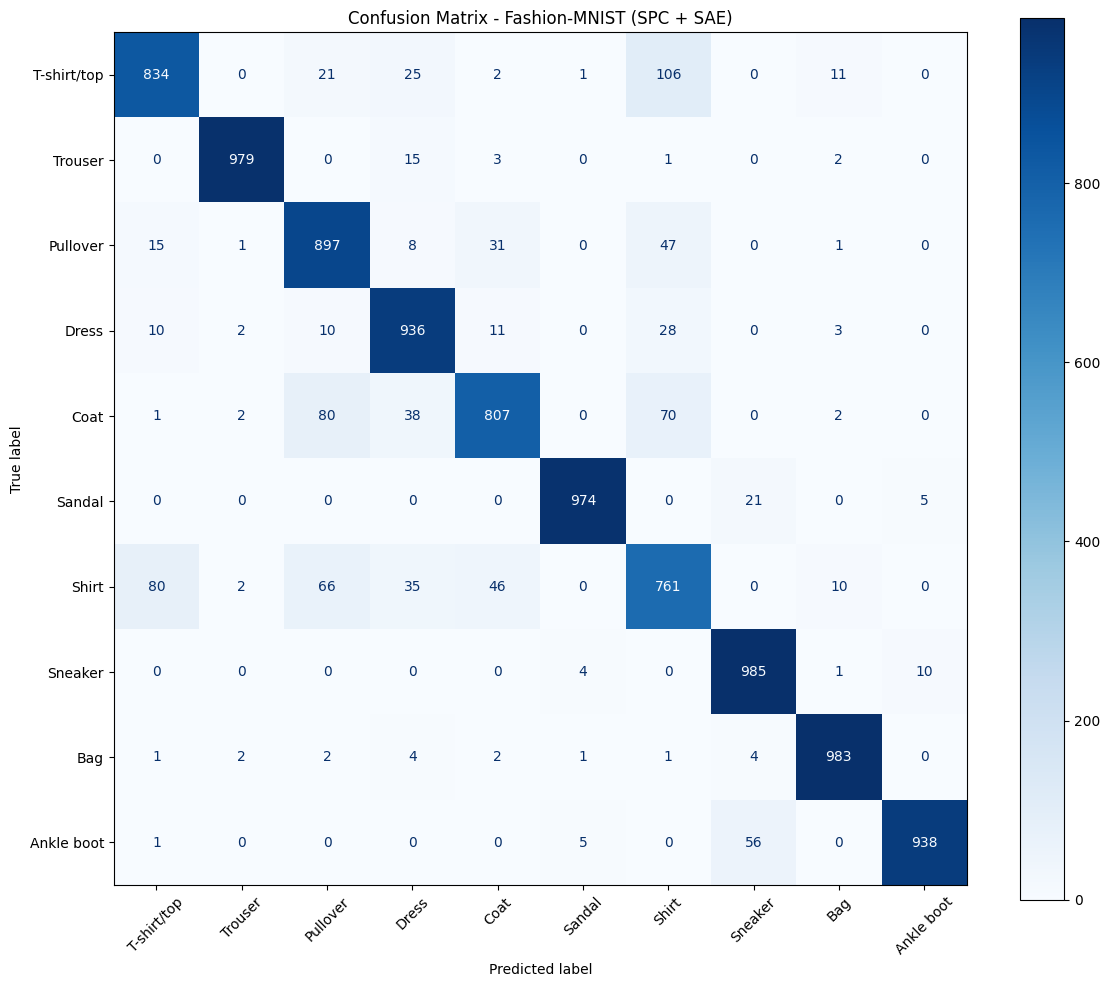

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_fashion_mnist_cm(net, testloader, spc_mask, device):
    net.eval()
    all_preds = []
    all_labels = []
    
    
    classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
        
            masked_inputs = inputs * spc_mask
            
            _, y_hat = net(masked_inputs)
            _, predicted = torch.max(y_hat.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45, values_format='d')
    
    plt.title("Confusion Matrix - Fashion-MNIST (SPC + SAE)")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    
    trained_net, mask = train(weight=0.1, num_epochs=7, tau=0.05)
    
    
    plot_fashion_mnist_cm(trained_net, testloader, mask, device)

Using device: cpu
Generating SPC mask for CIFAR-10...
Starting Training: Tau=0.01, Recon_Weight=0.1
Epoch 1/10 - Train Acc: 0.4519 - Test Acc: 0.5654
Epoch 2/10 - Train Acc: 0.6073 - Test Acc: 0.6486
Epoch 3/10 - Train Acc: 0.6789 - Test Acc: 0.6658
Epoch 4/10 - Train Acc: 0.7265 - Test Acc: 0.7007
Epoch 5/10 - Train Acc: 0.7671 - Test Acc: 0.7112
Epoch 6/10 - Train Acc: 0.8040 - Test Acc: 0.7217
Epoch 7/10 - Train Acc: 0.8434 - Test Acc: 0.7216
Epoch 8/10 - Train Acc: 0.8766 - Test Acc: 0.7262
Epoch 9/10 - Train Acc: 0.9079 - Test Acc: 0.7137
Epoch 10/10 - Train Acc: 0.9304 - Test Acc: 0.7182


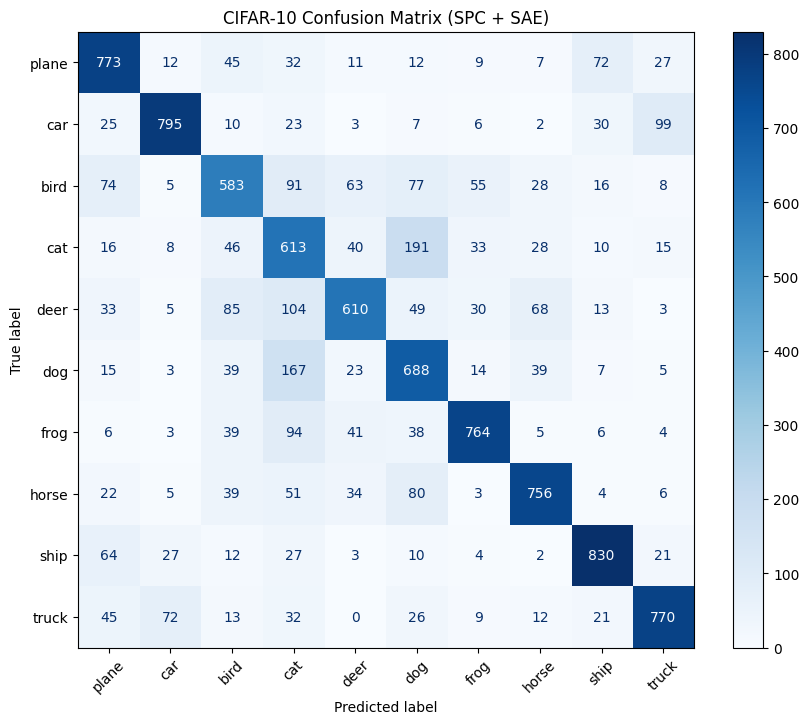

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_classif
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)


def get_spc_mask(dataloader, tau=0.02):
    """ 
    """
    print("Generating SPC mask for CIFAR-10...")
    X_list, y_list = [], []
    for i, (X, y) in enumerate(dataloader):
        X_list.append(X.view(X.shape[0], -1)) # 3072 
        y_list.append(y)
        if i > 40: break 
    
    X_f = torch.cat(X_list).numpy()
    y_f = torch.cat(y_list).numpy()
    
    #  F 
    f_scores, _ = f_classif(X_f, y_f)
    f_scores = np.nan_to_num(f_scores)

    threshold = tau * np.max(f_scores)
    mask = (f_scores >= threshold).astype(np.float32)
    return torch.from_numpy(mask).view(3, 32, 32).to(device)


class ConvNetCIFAR_SAE(nn.Module):
    def __init__(self):
        super(ConvNetCIFAR_SAE, self).__init__()
      
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Bottleneck: 32x32 -> 16x16 -> 8x8. 64*8*8 = 4096
        self.fc_enc1 = nn.Linear(4096, 256)
        self.fc_enc2 = nn.Linear(256, 64) #  64 

        # Decoder
        self.fc_dec1 = nn.Linear(64, 256)
        self.fc_dec2 = nn.Linear(256, 4096)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.deconv2 = nn.ConvTranspose2d(32, 3, kernel_size=2, stride=2)

        # Classifier Branch
        self.classifier = nn.Linear(64, 10)

    def forward(self, x):
        batch_size = x.size(0)
        # Encoder
        z = F.relu(self.conv1(x))
        z = self.pool1(z)
        z = F.relu(self.conv2(z))
        z = self.pool2(z)
        
        z = z.view(batch_size, -1)
        z = F.relu(self.fc_enc1(z))
        z_latent = F.relu(self.fc_enc2(z))

        # Decoder
        d = F.relu(self.fc_dec1(z_latent))
        d = F.relu(self.fc_dec2(d))
        d = d.view(batch_size, 64, 8, 8)
        d = F.relu(self.deconv1(d))
        x_hat = torch.tanh(self.deconv2(d))

        # Classification
        y_hat = self.classifier(z_latent)
        return x_hat, y_hat


def train_and_eval(weight=0.1, num_epochs=10, tau=0.02):
    spc_mask = get_spc_mask(trainloader, tau=tau)
    net = ConvNetCIFAR_SAE().to(device)
    
    cls_criterion = nn.CrossEntropyLoss()
    rec_criterion = nn.MSELoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)

    print(f"Starting Training: Tau={tau}, Recon_Weight={weight}")
    
    for epoch in range(num_epochs):
        
        net.train()
        train_correct, total = 0, 0
        for i, (inputs, labels) in enumerate(trainloader):
            inputs, labels = inputs.to(device), labels.to(device)
            masked_inputs = inputs * spc_mask 
            
            optimizer.zero_grad()
            x_hat, y_hat = net(masked_inputs)
            
            loss = cls_criterion(y_hat, labels) + weight * rec_criterion(x_hat, inputs)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(y_hat.data, 1)
            train_correct += (predicted == labels).sum().item()
            total += labels.size(0)
        
        train_acc = train_correct / total

        
        net.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                _, y_hat = net(inputs * spc_mask)
                _, predicted = torch.max(y_hat.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
        
        test_acc = test_correct / test_total
        print(f"Epoch {epoch+1}/{num_epochs} - Train Acc: {train_acc:.4f} - Test Acc: {test_acc:.4f}")

    return net, spc_mask


def plot_cifar_cm(net, loader, mask, device):
    net.eval()
    all_preds, all_labels = [], []
    classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            _, y_hat = net(inputs * mask)
            all_preds.extend(torch.argmax(y_hat, 1).cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title("CIFAR-10 Confusion Matrix (SPC + SAE)")
    plt.show()


if __name__ == "__main__":
    trained_net, final_mask = train_and_eval(weight=0.1, num_epochs=10, tau=0.01)
    plot_cifar_cm(trained_net, testloader, final_mask, device)

SAE+PCA


start train ConvNet SAE (bottleneck D: 32)...
Epoch 1 finish
Epoch 2 finish
Epoch 3 finish
Epoch 4 finish
Epoch 5 finish
Epoch 6 finish
Epoch 7 finish
Epoch 8 finish
Epoch 9 finish
Epoch 10 finish

execute PCA select...
 2: ac=0.7411, MSE=0.3064
 4: ac=0.9708, MSE=0.2651
 8: ac=0.9904, MSE=0.2182
 16: ac=0.9913, MSE=0.0937
 32: ac=0.9908, MSE=0.0618


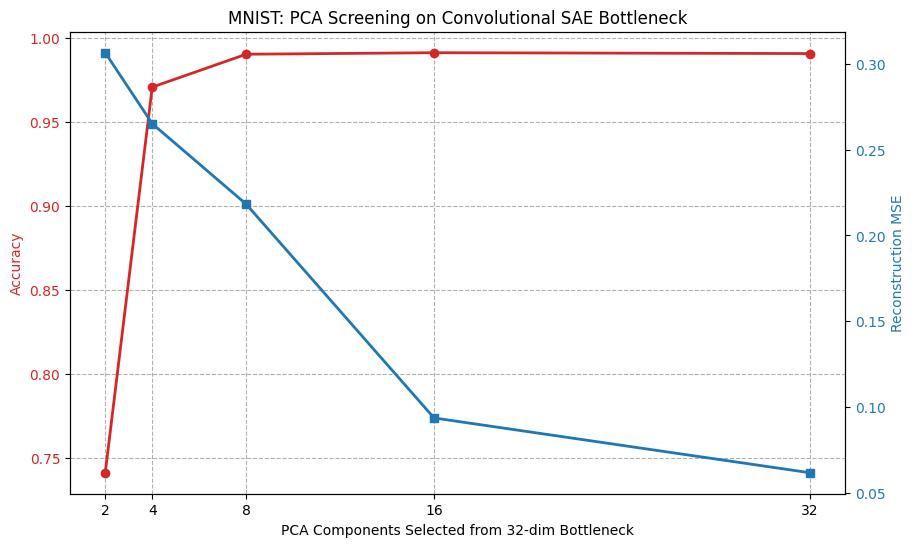

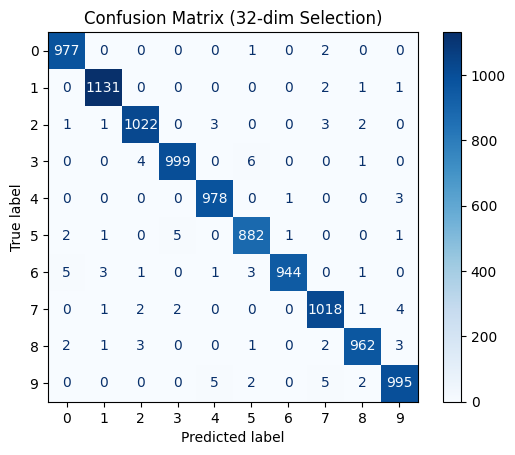

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs_sae = 10 
initial_latent_dim = 32  # output of bottleneck is 32D
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader = DataLoader(torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(torchvision.datasets.MNIST('./data', train=False, transform=transform), batch_size=batch_size, shuffle=False)

# --- 2.  SAE model ---
class ConvNetMNIST_SAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(ConvNetMNIST_SAE, self).__init__()
        # Encoder:  (28x28 -> 7x7)
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_enc = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, latent_dim) # final bottleneck
        )
        # Classifier:
        self.classifier = nn.Linear(latent_dim, 10)
        # Decoder
        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 32 * 7 * 7)
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, 2), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, 2), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder_conv(x).view(x.size(0), -1)
        z_latent = self.fc_enc(z)
        y_hat = self.classifier(z_latent)
        d = self.fc_dec(z_latent).view(-1, 32, 7, 7)
        x_hat = self.decoder_conv(d)
        return x_hat, y_hat, z_latent

# --- 3. train model---
model = ConvNetMNIST_SAE(latent_dim=initial_latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"start train ConvNet SAE (bottleneck D: {initial_latent_dim})...")
for epoch in range(epochs_sae):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        x_hat, y_hat, _ = model(imgs)
        loss = nn.CrossEntropyLoss()(y_hat, lbls) + 0.1 * F.mse_loss(x_hat, imgs)
        loss.backward(); optimizer.step()
    print(f"Epoch {epoch+1} finish")

# --- 4.  PCA ---
def extract_features(loader):
    model.eval()
    zs, ys, raw_imgs = [], [], []
    with torch.no_grad():
        for img, lbl in loader:
            _, _, z = model(img.to(device))
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
            raw_imgs.append(img.numpy())
    return np.vstack(zs), np.hstack(ys), np.vstack(raw_imgs)

Z_train, Y_train, _ = extract_features(train_loader)
Z_test, Y_test, X_test_raw = extract_features(test_loader)

# --- 5. PCA  (2, 4, 8, 16, 32) ---
pca_dims = [2, 4, 8, 16, 32]
acc_list, mse_list = [], []
final_y_pred = None



print("\nexecute PCA select...")
for d in pca_dims:
    # 1.  PCA 
    pca = PCA(n_components=d)
    Z_train_pca = pca.fit_transform(Z_train)
    Z_test_pca = pca.transform(Z_test)
    
    # 2. classifer Logistic Regression)
    clf = LogisticRegression(max_iter=1000).fit(Z_train_pca, Y_train)
    acc = clf.score(Z_test_pca, Y_test)
    acc_list.append(acc)
    
    # 3. re
    # PCA  32 D -> Decoder
    Z_back = pca.inverse_transform(Z_test_pca)
    Z_back_torch = torch.tensor(Z_back, dtype=torch.float32).to(device)
    with torch.no_grad():
        #  Decoder
        d_rec = model.fc_dec(Z_back_torch).view(-1, 32, 7, 7)
        x_rec = model.decoder_conv(d_rec).cpu().numpy()
    
    mse = np.mean((X_test_raw - x_rec)**2)
    mse_list.append(mse)
    
    print(f" {d}: ac={acc:.4f}, MSE={mse:.4f}")
    if d == 32: final_y_pred = clf.predict(Z_test_pca)

# --- 6. plo ---
fig, ax1 = plt.subplots(figsize=(10, 6))


ax1.set_xlabel('PCA Components Selected from 32-dim Bottleneck')
ax1.set_ylabel('Accuracy', color='tab:red')
ax1.plot(pca_dims, acc_list, marker='o', color='tab:red', label='Accuracy', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_xticks(pca_dims)

# 
ax2 = ax1.twinx()
ax2.set_ylabel('Reconstruction MSE', color='tab:blue')
ax2.plot(pca_dims, mse_list, marker='s', color='tab:blue', label='MSE', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('MNIST: PCA Screening on Convolutional SAE Bottleneck')
ax1.grid(True, linestyle='--')
plt.show()

# 
ConfusionMatrixDisplay.from_predictions(Y_test, final_y_pred, cmap='Blues', display_labels=range(10))
plt.title("Confusion Matrix (32-dim Selection)")
plt.show()

start train ConvNet SAE (: 32)...
Epoch 1 finish
Epoch 2 finish
Epoch 3 finish
Epoch 4 finish
Epoch 5 finish
Epoch 6 finish
Epoch 7 finish
Epoch 8 finish
Epoch 9 finish
Epoch 10 finish

start execute PCA D...
Dim 2: ac=0.6780, MSE=0.2791
Dim 4: ac=0.8309, MSE=0.2416
Dim 8: ac=0.9115, MSE=0.1754
Dim 16: ac=0.9164, MSE=0.0885
Dim 32: ac=0.9186, MSE=0.0762


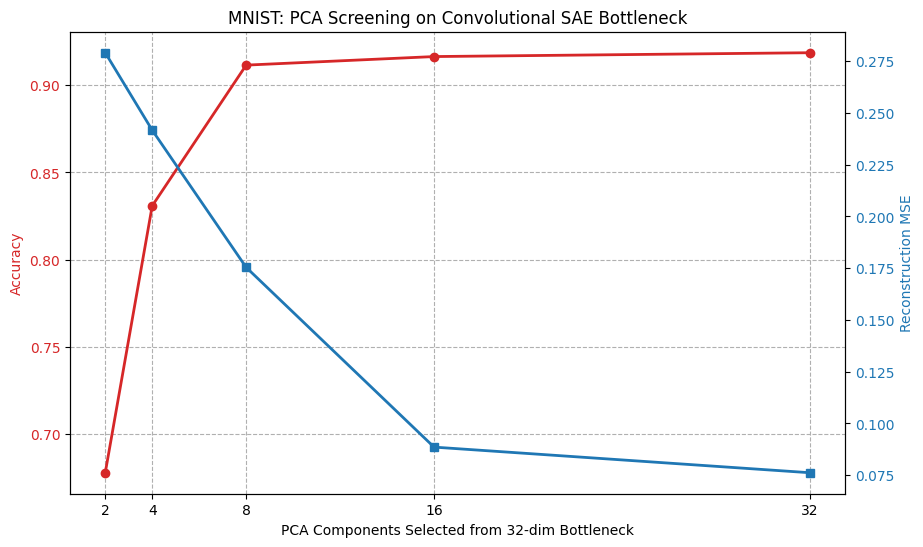

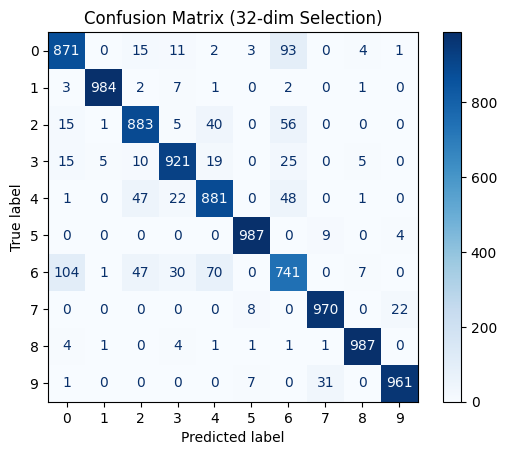

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --- 1.  ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs_sae = 10 
initial_latent_dim = 32  

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader = DataLoader(torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(torchvision.datasets.FashionMNIST('./data', train=False, transform=transform), batch_size=batch_size, shuffle=False)

# --- 2.  SAE  ---
class ConvNetMNIST_SAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(ConvNetMNIST_SAE, self).__init__()
        # Encoder: 
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_enc = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, latent_dim) # 
        )
        # Classifier:
        self.classifier = nn.Linear(latent_dim, 10)
        # Decoder: 
        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 32 * 7 * 7)
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, 2), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, 2), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder_conv(x).view(x.size(0), -1)
        z_latent = self.fc_enc(z)
        y_hat = self.classifier(z_latent)
        d = self.fc_dec(z_latent).view(-1, 32, 7, 7)
        x_hat = self.decoder_conv(d)
        return x_hat, y_hat, z_latent

# --- 3. model train---
model = ConvNetMNIST_SAE(latent_dim=initial_latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"start train ConvNet SAE (: {initial_latent_dim})...")
for epoch in range(epochs_sae):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        x_hat, y_hat, _ = model(imgs)
        loss = nn.CrossEntropyLoss()(y_hat, lbls) + 0.1 * F.mse_loss(x_hat, imgs)
        loss.backward(); optimizer.step()
    print(f"Epoch {epoch+1} finish")

# --- 4.  PCA ---
def extract_features(loader):
    model.eval()
    zs, ys, raw_imgs = [], [], []
    with torch.no_grad():
        for img, lbl in loader:
            _, _, z = model(img.to(device))
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
            raw_imgs.append(img.numpy())
    return np.vstack(zs), np.hstack(ys), np.vstack(raw_imgs)

Z_train, Y_train, _ = extract_features(train_loader)
Z_test, Y_test, X_test_raw = extract_features(test_loader)

# --- 5. PCA  (2, 4, 8, 16, 32) ---
pca_dims = [2, 4, 8, 16, 32]
acc_list, mse_list = [], []
final_y_pred = None



print("\nstart execute PCA D...")
for d in pca_dims:
    # 1.execute PCA 
    pca = PCA(n_components=d)
    Z_train_pca = pca.fit_transform(Z_train)
    Z_test_pca = pca.transform(Z_test)
    
    # 2. Logistic Regression
    clf = LogisticRegression(max_iter=1000).fit(Z_train_pca, Y_train)
    acc = clf.score(Z_test_pca, Y_test)
    acc_list.append(acc)
    
    # 3. re
    # PCA  32  -> Decoder 
    Z_back = pca.inverse_transform(Z_test_pca)
    Z_back_torch = torch.tensor(Z_back, dtype=torch.float32).to(device)
    with torch.no_grad():
        # 
        d_rec = model.fc_dec(Z_back_torch).view(-1, 32, 7, 7)
        x_rec = model.decoder_conv(d_rec).cpu().numpy()
    
    mse = np.mean((X_test_raw - x_rec)**2)
    mse_list.append(mse)
    
    print(f"Dim {d}: ac={acc:.4f}, MSE={mse:.4f}")
    if d == 32: final_y_pred = clf.predict(Z_test_pca)

# --- 6. plo ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# 
ax1.set_xlabel('PCA Components Selected from 32-dim Bottleneck')
ax1.set_ylabel('Accuracy', color='tab:red')
ax1.plot(pca_dims, acc_list, marker='o', color='tab:red', label='Accuracy', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_xticks(pca_dims)

# 
ax2 = ax1.twinx()
ax2.set_ylabel('Reconstruction MSE', color='tab:blue')
ax2.plot(pca_dims, mse_list, marker='s', color='tab:blue', label='MSE', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('MNIST: PCA Screening on Convolutional SAE Bottleneck')
ax1.grid(True, linestyle='--')
plt.show()

# 
ConfusionMatrixDisplay.from_predictions(Y_test, final_y_pred, cmap='Blues', display_labels=range(10))
plt.title("Confusion Matrix (32-dim Selection)")
plt.show()

Epoch 1 finished
Epoch 2 finished
Epoch 3 finished
Epoch 4 finished
Epoch 5 finished
Epoch 6 finished
Epoch 7 finished

execute PCA select...
dim 2: acc=0.3835, MSE=0.2348
dim 4: acc=0.6051, MSE=0.2328
dim 8: acc=0.7195, MSE=0.2245
dim 16: acc=0.7270, MSE=0.1439
dim 32: acc=0.7295, MSE=0.1190
dim 64: acc=0.7275, MSE=0.1100


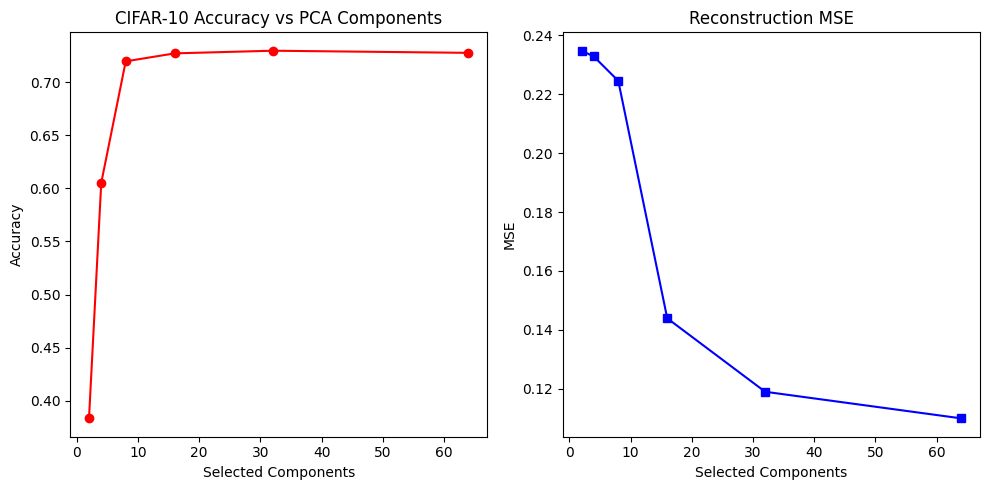

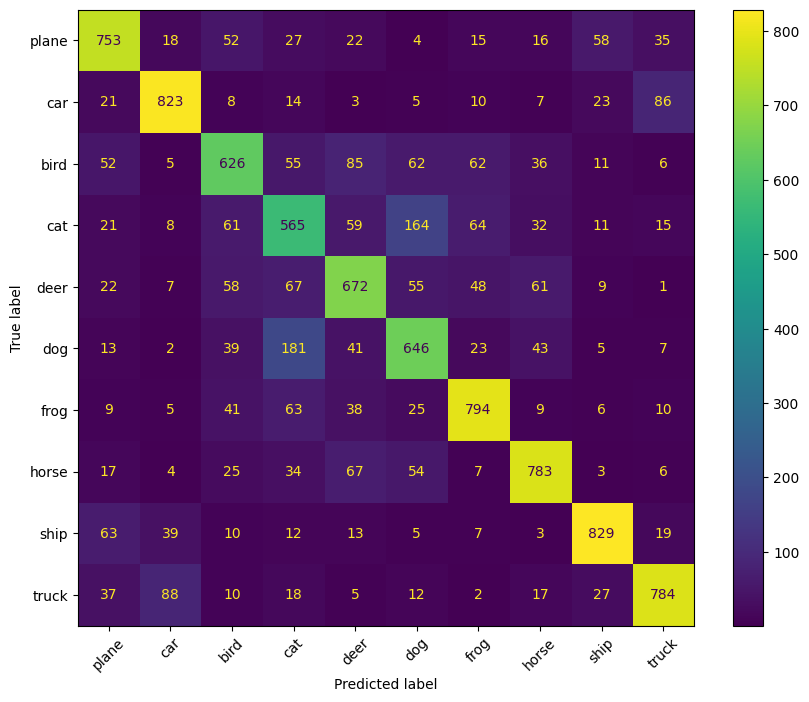

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --- 1. ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs_sae = 7  # CIFAR-10 
initial_latent_dim = 64 # 

# 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_loader = DataLoader(torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(torchvision.datasets.CIFAR10('./data', train=False, transform=transform), batch_size=batch_size, shuffle=False)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# --- 2.---
class CIFAR10_SAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(CIFAR10_SAE, self).__init__()
        # Encoder: 32x32 -> 8x8
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_enc = nn.Sequential(
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        # Classifier & Decoder
        self.classifier = nn.Linear(latent_dim, 10)
        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 64 * 8 * 8)
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder_conv(x).view(x.size(0), -1)
        z_latent = self.fc_enc(z)
        y_hat = self.classifier(z_latent)
        d = self.fc_dec(z_latent).view(-1, 64, 8, 8)
        x_hat = self.decoder_conv(d)
        return x_hat, y_hat, z_latent

# --- 3. train---
model = CIFAR10_SAE(latent_dim=initial_latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)


for epoch in range(epochs_sae):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        x_hat, y_hat, _ = model(imgs)
        # 
        loss = nn.CrossEntropyLoss()(y_hat, lbls) + 0.1 * F.mse_loss(x_hat, imgs)
        loss.backward(); optimizer.step()
    print(f"Epoch {epoch+1} finished")

# --- 4.---
def extract_features(loader):
    model.eval()
    zs, ys, raw_imgs = [], [], []
    with torch.no_grad():
        for img, lbl in loader:
            _, _, z = model(img.to(device))
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
            raw_imgs.append(img.numpy())
    return np.vstack(zs), np.hstack(ys), np.vstack(raw_imgs)

Z_train, Y_train, _ = extract_features(train_loader)
Z_test, Y_test, X_test_raw = extract_features(test_loader)

# PCA
pca_dims = [2, 4, 8, 16, 32, 64]
acc_list, mse_list = [], []



print("\nexecute PCA select...")
for d in pca_dims:
    pca = PCA(n_components=d)
    Z_train_pca = pca.fit_transform(Z_train)
    Z_test_pca = pca.transform(Z_test)
    
    # 
    clf = LogisticRegression(max_iter=1000).fit(Z_train_pca, Y_train)
    acc = clf.score(Z_test_pca, Y_test)
    acc_list.append(acc)
    
    # 
    Z_back = torch.tensor(pca.inverse_transform(Z_test_pca), dtype=torch.float32).to(device)
    with torch.no_grad():
        d_rec = model.fc_dec(Z_back).view(-1, 64, 8, 8)
        x_rec = model.decoder_conv(d_rec).cpu().numpy()
    mse = np.mean((X_test_raw - x_rec)**2)
    mse_list.append(mse)
    print(f"dim {d}: acc={acc:.4f}, MSE={mse:.4f}")

# --- 5. 绘图 ---
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(pca_dims, acc_list, 'o-r')
plt.title("CIFAR-10 Accuracy vs PCA Components")
plt.xlabel("Selected Components")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(pca_dims, mse_list, 's-b')
plt.title("Reconstruction MSE")
plt.xlabel("Selected Components")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

# 
ConfusionMatrixDisplay.from_predictions(Y_test, clf.predict(Z_test_pca), display_labels=classes, xticks_rotation=45).figure_.set_size_inches(10, 8)
plt.show()

AE+SPCA

Step 1: training AE ...
Epoch 1 finish
Epoch 2 finish
Epoch 3 finish
Epoch 4 finish
Epoch 5 finish
Epoch 6 finish
Epoch 7 finish

Step 2: execute spca...
SPCA select 2 -> acc: 0.4130
SPCA select 4 -> acc: 0.5559
SPCA select 8 -> acc: 0.7467
SPCA select 16 -> acc: 0.8425


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SPCA select 32 -> acc: 0.9243
SPCA select 64 -> acc: 0.9289


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


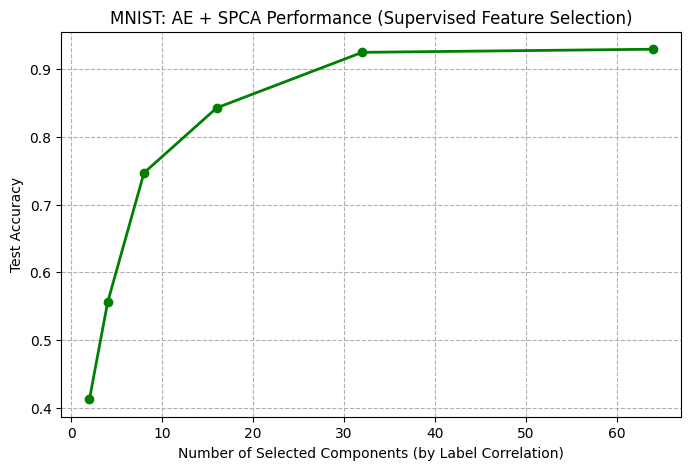

c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


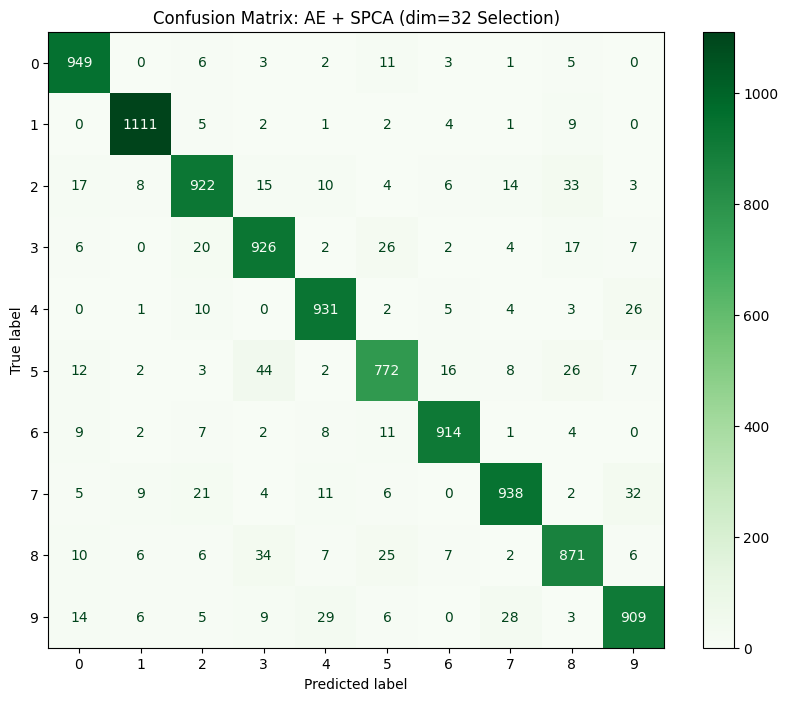

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
initial_latent_dim = 64  # 

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform), 
    batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=False, transform=transform), 
    batch_size=batch_size, shuffle=False)


class Pure_AE(nn.Module):
    def __init__(self, latent_dim=64):
        super(Pure_AE, self).__init__()
        # Encoder: 
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        # Decoder: 
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


model = Pure_AE(latent_dim=initial_latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Step 1: training AE ...")
for epoch in range(7):
    model.train()
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        x_hat, _ = model(imgs)
        loss = nn.MSELoss()(x_hat, imgs)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} finish")


def get_latent_data(loader):
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for img, lbl in loader:
            _, z = model(img.to(device))
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
    return np.vstack(zs), np.hstack(ys)

Z_train, Y_train = get_latent_data(train_loader)
Z_test, Y_test = get_latent_data(test_loader)


dims = [2, 4, 8, 16, 32, 64]
accuracies = []

print("\nStep 2: execute spca...")



for d in dims:
    
    selector = SelectKBest(score_func=f_classif, k=d)
    Z_train_selected = selector.fit_transform(Z_train, Y_train)
    Z_test_selected = selector.transform(Z_test)
    
    
    clf = LogisticRegression(max_iter=1000).fit(Z_train_selected, Y_train)
    acc = clf.score(Z_test_selected, Y_test)
    accuracies.append(acc)
    print(f"SPCA select {d} -> acc: {acc:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(dims, accuracies, 'o-g', linewidth=2)
plt.title("MNIST: AE + SPCA Performance (Supervised Feature Selection)")
plt.xlabel("Number of Selected Components (by Label Correlation)")
plt.ylabel("Test Accuracy")
plt.grid(True, linestyle='--')
plt.show()


selector_32 = SelectKBest(score_func=f_classif, k=32)
Z_train_32 = selector_32.fit_transform(Z_train, Y_train)
Z_test_32 = selector_32.transform(Z_test)
clf_32 = LogisticRegression(max_iter=1000).fit(Z_train_32, Y_train)
y_pred = clf_32.predict(Z_test_32)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(Y_test, y_pred, cmap='Greens', ax=ax)
plt.title("Confusion Matrix: AE + SPCA (dim=32 Selection)")
plt.show()

Step 1: training Fashion-MNIST...
Epoch 1, Loss: 0.0916
Epoch 2, Loss: 0.0484
Epoch 3, Loss: 0.0409
Epoch 4, Loss: 0.0367
Epoch 5, Loss: 0.0341
Epoch 6, Loss: 0.0321
Epoch 7, Loss: 0.0306
Epoch 8, Loss: 0.0294
Epoch 9, Loss: 0.0284
Epoch 10, Loss: 0.0276

Step 2: execute SPCA select (Supervised Selection)...
D 2 -> acc: 0.4161
D 4 -> acc: 0.5244
D 8 -> acc: 0.6361
D 16 -> acc: 0.7417
D 32 -> acc: 0.8221
D 64 -> acc: 0.8553


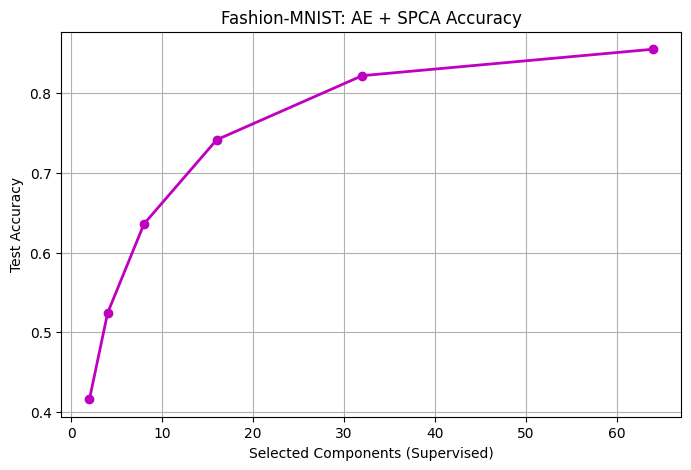

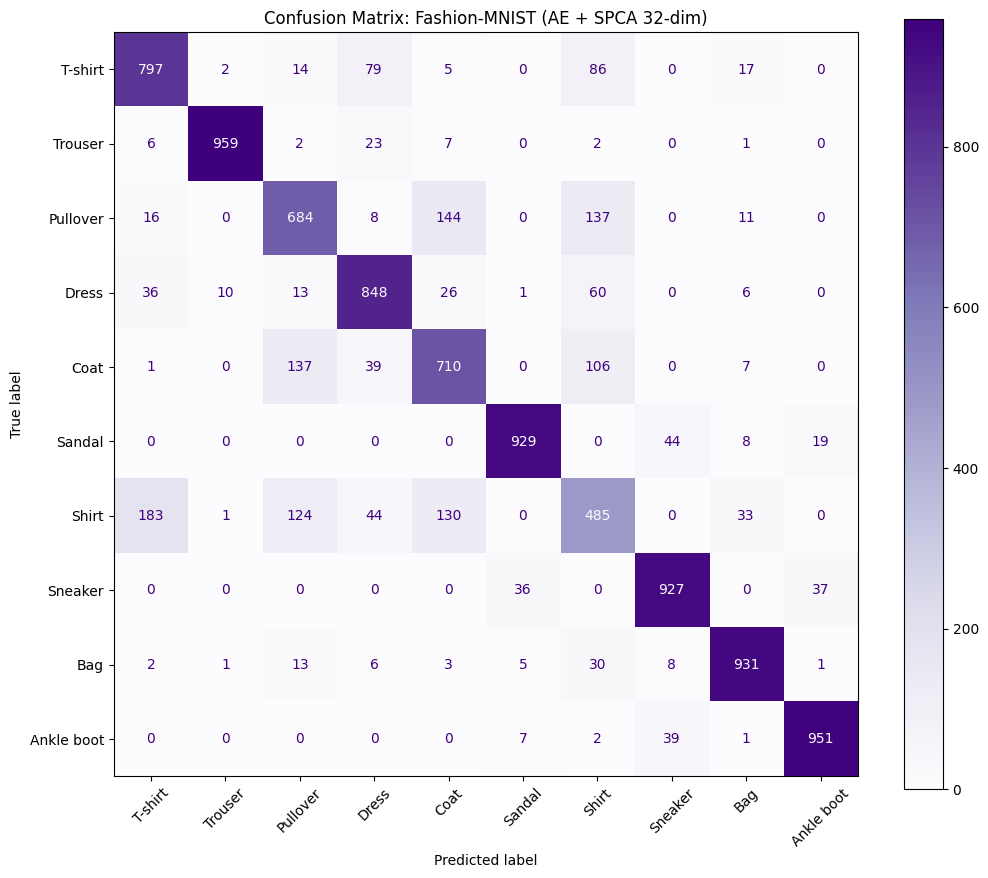

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
initial_latent_dim = 64 # 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


train_set = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


class Fashion_AE(nn.Module):
    def __init__(self, latent_dim=64):
        super(Fashion_AE, self).__init__()
        # Encoder:
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 64 * 7 * 7),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 2, stride=2), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


model = Fashion_AE(latent_dim=initial_latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Step 1: training Fashion-MNIST...")
for epoch in range(10):
    model.train()
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        x_hat, _ = model(imgs)
        loss = nn.MSELoss()(x_hat, imgs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

#
def get_features(loader):
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for img, lbl in loader:
            _, z = model(img.to(device))
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
    return np.vstack(zs), np.hstack(ys)

Z_train, Y_train = get_features(train_loader)
Z_test, Y_test = get_features(test_loader)


dims = [2, 4, 8, 16, 32, 64]
accuracies = []



print("\nStep 2: execute SPCA select (Supervised Selection)...")
for d in dims:
    
    selector = SelectKBest(score_func=f_classif, k=d)
    Z_train_sel = selector.fit_transform(Z_train, Y_train)
    Z_test_sel = selector.transform(Z_test)
    
    
    clf = LogisticRegression(max_iter=1000).fit(Z_train_sel, Y_train)
    acc = clf.score(Z_test_sel, Y_test)
    accuracies.append(acc)
    print(f"D {d} -> acc: {acc:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(dims, accuracies, 'o-m', linewidth=2)
plt.title("Fashion-MNIST: AE + SPCA Accuracy")
plt.xlabel("Selected Components (Supervised)")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()


selector_32 = SelectKBest(score_func=f_classif, k=32)
Z_train_32 = selector_32.fit_transform(Z_train, Y_train)
Z_test_32 = selector_32.transform(Z_test)
clf_32 = LogisticRegression(max_iter=1000).fit(Z_train_32, Y_train)
y_pred = clf_32.predict(Z_test_32)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(Y_test, y_pred, display_labels=classes, cmap='Purples', ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Fashion-MNIST (AE + SPCA 32-dim)")
plt.show()

Step 1: train CIFAR-10 ae...
Epoch 1 finish
Epoch 2 finish
Epoch 3 finish
Epoch 4 finish
Epoch 5 finish
Epoch 6 finish
Epoch 7 finish
Epoch 8 finish
Epoch 9 finish
Epoch 10 finish

Step 2: execute spca...
DIM 8 -> ACC: 0.2723
DIM 16 -> ACC: 0.3109
DIM 32 -> ACC: 0.3521
DIM 64 -> ACC: 0.4160
DIM 128 -> ACC: 0.4744


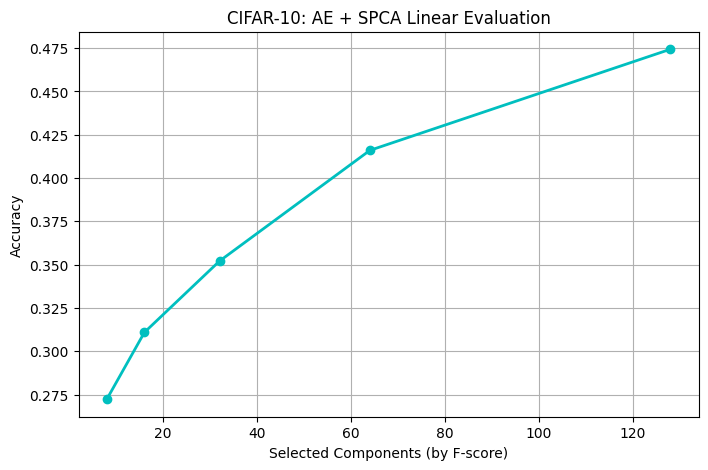

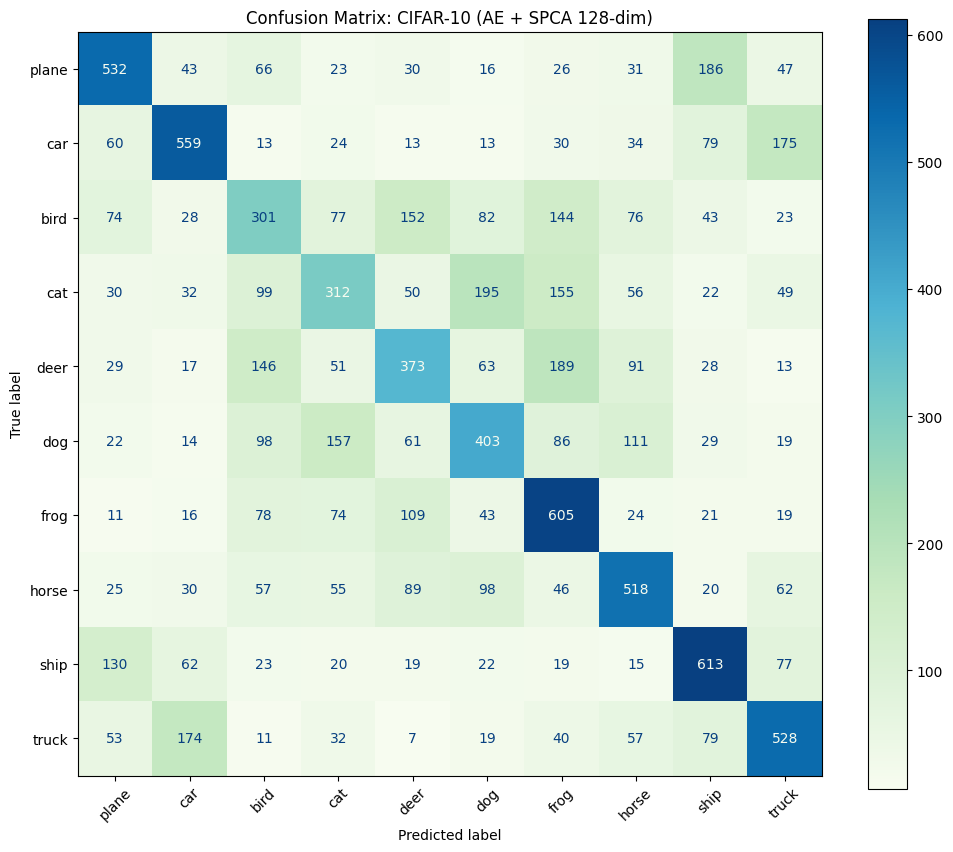

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
initial_latent_dim = 128 # CIFAR-10 has high complexity, set the bottleneck layer to 128.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# --- 2.  ---
class CIFAR_AE(nn.Module):
    def __init__(self, latent_dim=128):
        super(CIFAR_AE, self).__init__()
        # Encoder: 32x32 -> 8x8
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512), nn.ReLU(),
            nn.Linear(512, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512), nn.ReLU(),
            nn.Linear(512, 128 * 4 * 4),
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

# ---  ---
model = CIFAR_AE(latent_dim=initial_latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Step 1: train CIFAR-10 ae...")
for epoch in range(10): 
    model.train()
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        x_hat, _ = model(imgs)
        loss = nn.MSELoss()(x_hat, imgs)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} finish")

# --- 4.SPCA ---
def get_features(loader):
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for img, lbl in loader:
            _, z = model(img.to(device))
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
    return np.vstack(zs), np.hstack(ys)

Z_train, Y_train = get_features(train_loader)
Z_test, Y_test = get_features(test_loader)

# 
dims = [8, 16, 32, 64, 128]
accuracies = []



print("\nStep 2: execute spca...")
for d in dims:
    selector = SelectKBest(score_func=f_classif, k=d)
    Z_train_sel = selector.fit_transform(Z_train, Y_train)
    Z_test_sel = selector.transform(Z_test)
    
    clf = LogisticRegression(max_iter=2000).fit(Z_train_sel, Y_train)
    acc = clf.score(Z_test_sel, Y_test)
    accuracies.append(acc)
    print(f"DIM {d} -> ACC: {acc:.4f}")

# 
plt.figure(figsize=(8, 5))
plt.plot(dims, accuracies, 'o-c', linewidth=2)
plt.title("CIFAR-10: AE + SPCA Linear Evaluation")
plt.xlabel("Selected Components (by F-score)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# 
selector_128 = SelectKBest(score_func=f_classif, k=128)
Z_train_128 = selector_128.fit_transform(Z_train, Y_train)
Z_test_128 = selector_128.transform(Z_test)
clf_128 = LogisticRegression(max_iter=2000).fit(Z_train_128, Y_train)
y_pred = clf_128.predict(Z_test_128)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(Y_test, y_pred, display_labels=classes, cmap='GnBu', ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: CIFAR-10 (AE + SPCA 128-dim)")
plt.show()

In [ ]:
#receptive field
import pandas as pd

def calculate_rf_for_shallow_ae():
    # initial state
    rf = 1.0     # Receptive Field
    jump = 1.0   #  One pixel in the current layer represents the distance from the original image.(Total Stride)
    
    
    # Conv1 -> Pool1 -> Conv2 -> Pool2
    layers = [
        {"name": "Conv1 (3x3, s1, p1)", "k": 3, "s": 1, "p": 1},
        {"name": "MaxPool1 (2x2, s2)",  "k": 2, "s": 2, "p": 0},
        {"name": "Conv2 (3x3, s1, p1)", "k": 3, "s": 1, "p": 1},
        {"name": "MaxPool2 (2x2, s2)",  "k": 2, "s": 2, "p": 0}
    ]
    
    results = []
    results.append({"Layer": "Input Image", "RF": 1, "Jump": 1})

    for layer in layers:
        k, s = layer['k'], layer['s']
        # RF core formula: RF_out = RF_in + (k - 1) * Jump_in
        rf = rf + (k - 1) * jump
        #Jump core formula: Jump_out = Jump_in * stride
        jump = jump * s
        
        results.append({
            "Layer": layer['name'],
            "RF": int(rf),
            "Jump": int(jump)
        })
    
    return pd.DataFrame(results)

# Execute and print
df_rf = calculate_rf_for_shallow_ae()
print("=== Shallow CIFAR_AE Receptive Field Evolution ===")
print(df_rf)

=== Shallow CIFAR_AE Receptive Field Evolution ===
                 Layer  RF  Jump
0          Input Image   1     1
1  Conv1 (3x3, s1, p1)   3     1
2   MaxPool1 (2x2, s2)   4     2
3  Conv2 (3x3, s1, p1)   8     2
4   MaxPool2 (2x2, s2)  10     4


Step 1: train AE...


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

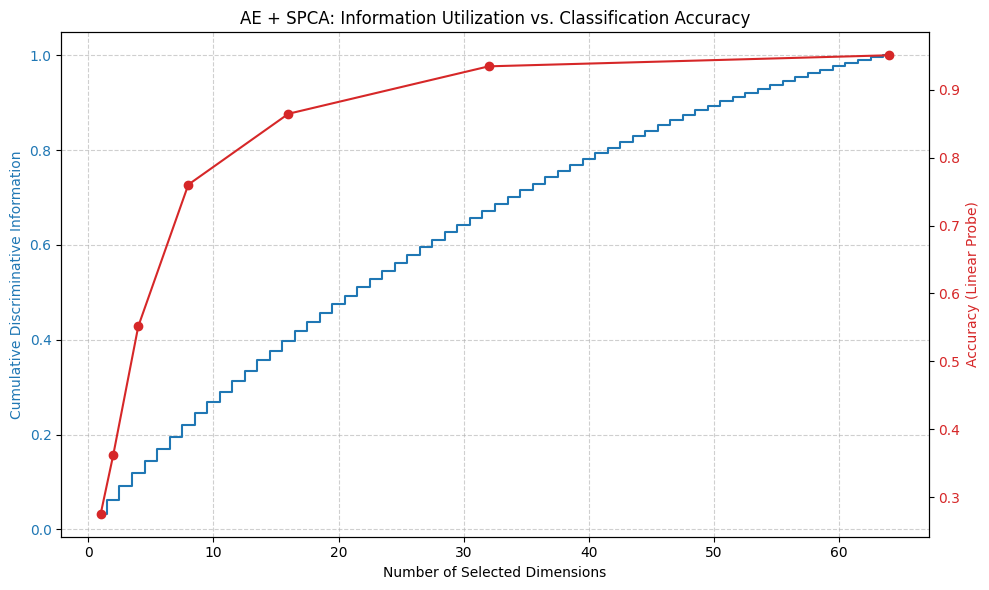

top 8 D use information percent: 22.08%
top 8 D acc: 76.02%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
latent_dim = 64  # Original bottleneck layer dimension

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform), 
    batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=False, transform=transform), 
    batch_size=batch_size, shuffle=False)

# --- 2.  (AE1) ---
class Pure_AE(nn.Module):
    def __init__(self, latent_dim=64):
        super(Pure_AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

# --- 3. train AE1 (Unsupervised) ---
model = Pure_AE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Step 1: train AE...")
for epoch in range(5):
    model.train()
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        x_hat, _ = model(imgs)
        loss = nn.MSELoss()(x_hat, imgs)
        loss.backward()
        optimizer.step()

# --- 4. Feature extraction and SPCA screening---
model.eval()
zs, ys = [], []
with torch.no_grad():
    for img, lbl in test_loader:
        _, z = model(img.to(device))
        zs.append(z.cpu().numpy())
        ys.append(lbl.numpy())

Z_test = np.vstack(zs)
Y_test = np.hstack(ys)

# Use the F-test to calculate the supervision information score for each dimension.
f_scores, _ = f_classif(Z_test, Y_test)
# Normalized score represents the proportion of information contribution from each dimension.
info_contribution = f_scores / np.sum(f_scores)
# Sort in descending order and calculate cumulative information content
sorted_info = np.sort(info_contribution)[::-1]
cumulative_info = np.cumsum(sorted_info)

# --- 5. test ---
dims = [1, 2, 4, 8, 16, 32, 64]
acc_list = []

for d in dims:
    selector = SelectKBest(score_func=f_classif, k=d)
    # The filtering effect is directly displayed on the test set (for demonstration purposes only; it should actually be fitted on the training set).
    Z_selected = selector.fit_transform(Z_test, Y_test)
    clf = LogisticRegression(max_iter=1000).fit(Z_selected, Y_test)
    acc = clf.score(Z_selected, Y_test)
    acc_list.append(acc)

# --- 6. plo ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Drawing cumulative discriminant information (the core of SPCA)
ax1.set_xlabel('Number of Selected Dimensions')
ax1.set_ylabel('Cumulative Discriminative Information', color='tab:blue')
ax1.step(range(1, latent_dim + 1), cumulative_info, where='mid', color='tab:blue', label='Cumulative Info')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plotting accuracy curves
ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy (Linear Probe)', color='tab:red')
ax2.plot(dims, acc_list, marker='o', color='tab:red', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('AE + SPCA: Information Utilization vs. Classification Accuracy')
fig.tight_layout()
plt.show()

print(f"top 8 D use information percent: {cumulative_info[7]*100:.2f}%")
print(f"top 8 D acc: {acc_list[3]*100:.2f}%")

Step 1: train AE...


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


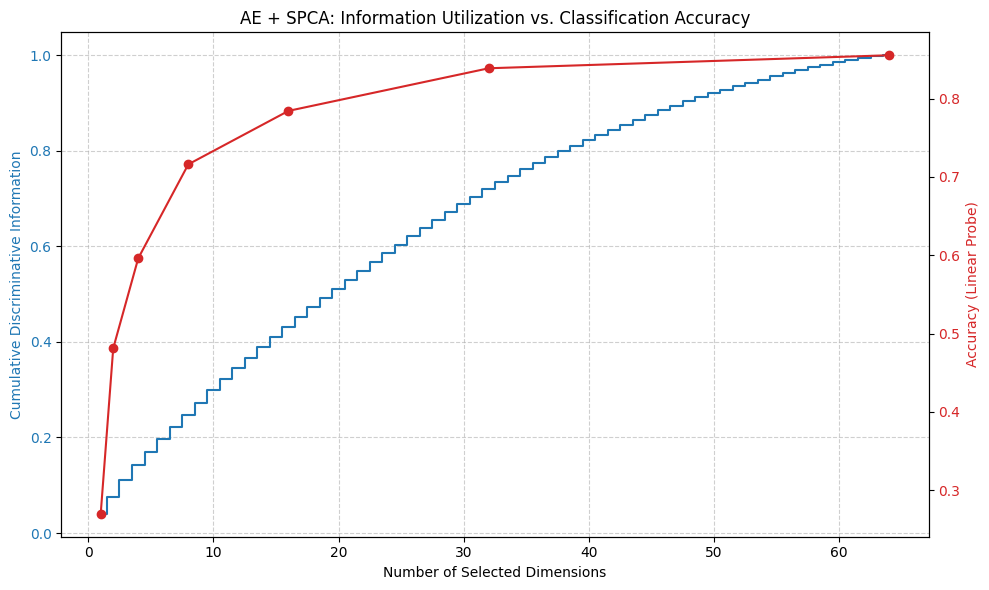

top 8 D use information percent: 24.76%
top 8 D acc: 71.60%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

#
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
latent_dim = 64  # Original bottleneck layer dimension

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform), 
    batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.FashionMNIST('./data', train=False, transform=transform), 
    batch_size=batch_size, shuffle=False)

# --- 2.  (AE1) ---
class Pure_AE(nn.Module):
    def __init__(self, latent_dim=64):
        super(Pure_AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

# --- 3. train ---
model = Pure_AE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Step 1: train AE...")
for epoch in range(5):
    model.train()
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        x_hat, _ = model(imgs)
        loss = nn.MSELoss()(x_hat, imgs)
        loss.backward()
        optimizer.step()

# --- 4.Feature extraction and SPCA screening ---
model.eval()
zs, ys = [], []
with torch.no_grad():
    for img, lbl in test_loader:
        _, z = model(img.to(device))
        zs.append(z.cpu().numpy())
        ys.append(lbl.numpy())

Z_test = np.vstack(zs)
Y_test = np.hstack(ys)


f_scores, _ = f_classif(Z_test, Y_test)

info_contribution = f_scores / np.sum(f_scores)

sorted_info = np.sort(info_contribution)[::-1]
cumulative_info = np.cumsum(sorted_info)


dims = [1, 2, 4, 8, 16, 32, 64]
acc_list = []

for d in dims:
    selector = SelectKBest(score_func=f_classif, k=d)
    # 
    Z_selected = selector.fit_transform(Z_test, Y_test)
    clf = LogisticRegression(max_iter=1000).fit(Z_selected, Y_test)
    acc = clf.score(Z_selected, Y_test)
    acc_list.append(acc)


fig, ax1 = plt.subplots(figsize=(10, 6))


ax1.set_xlabel('Number of Selected Dimensions')
ax1.set_ylabel('Cumulative Discriminative Information', color='tab:blue')
ax1.step(range(1, latent_dim + 1), cumulative_info, where='mid', color='tab:blue', label='Cumulative Info')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.6)


ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy (Linear Probe)', color='tab:red')
ax2.plot(dims, acc_list, marker='o', color='tab:red', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('AE + SPCA: Information Utilization vs. Classification Accuracy')
fig.tight_layout()
plt.show()

print(f"top 8 D use information percent: {cumulative_info[7]*100:.2f}%")
print(f"top 8 D acc: {acc_list[3]*100:.2f}%")

Step 1: train CIFAR-10 ...


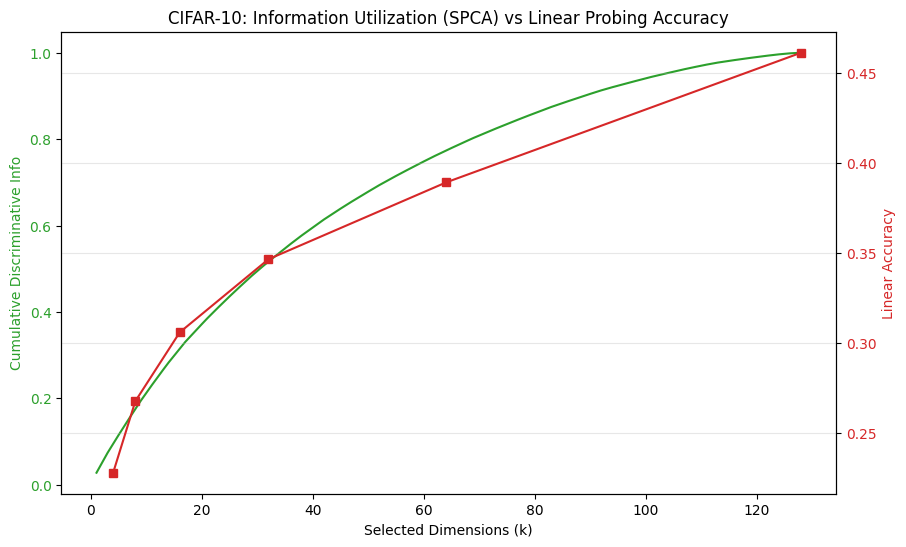

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
latent_dim = 128  

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform), 
    batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.CIFAR10('./data', train=False, transform=transform), 
    batch_size=batch_size, shuffle=False)


class CIFAR_AE(nn.Module):
    def __init__(self, latent_dim=128):
        super(CIFAR_AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 64 * 8 * 8),
            nn.Unflatten(1, (64, 8, 8)),
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


model = CIFAR_AE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Step 1: train CIFAR-10 ...")
for epoch in range(10):
    model.train()
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        x_hat, _ = model(imgs)
        loss = nn.MSELoss()(x_hat, imgs)
        loss.backward()
        optimizer.step()

model.eval()
zs_train, ys_train = [], []
zs_test, ys_test = [], []

with torch.no_grad():
    for img, lbl in train_loader:
        _, z = model(img.to(device))
        zs_train.append(z.cpu().numpy()); ys_train.append(lbl.numpy())
    for img, lbl in test_loader:
        _, z = model(img.to(device))
        zs_test.append(z.cpu().numpy()); ys_test.append(lbl.numpy())

Z_train, Y_train = np.vstack(zs_train), np.hstack(ys_train)
Z_test, Y_test = np.vstack(zs_test), np.hstack(ys_test)

f_scores, _ = f_classif(Z_train, Y_train)
info_contribution = f_scores / np.sum(f_scores)
cumulative_info = np.cumsum(np.sort(info_contribution)[::-1])


dims = [4, 8, 16, 32, 64, 128]
acc_list = []

for d in dims:
    selector = SelectKBest(score_func=f_classif, k=d)
    Z_train_sel = selector.fit_transform(Z_train, Y_train)
    Z_test_sel = selector.transform(Z_test)
    clf = LogisticRegression(max_iter=1000).fit(Z_train_sel, Y_train)
    acc_list.append(clf.score(Z_test_sel, Y_test))


fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Selected Dimensions (k)')
ax1.set_ylabel('Cumulative Discriminative Info', color='tab:green')
ax1.plot(range(1, latent_dim + 1), cumulative_info, color='tab:green', label='Info Contribution')
ax1.tick_params(axis='y', labelcolor='tab:green')

ax2 = ax1.twinx()
ax2.set_ylabel('Linear Accuracy', color='tab:red')
ax2.plot(dims, acc_list, marker='s', color='tab:red', label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('CIFAR-10: Information Utilization (SPCA) vs Linear Probing Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

caculate t-SNE...


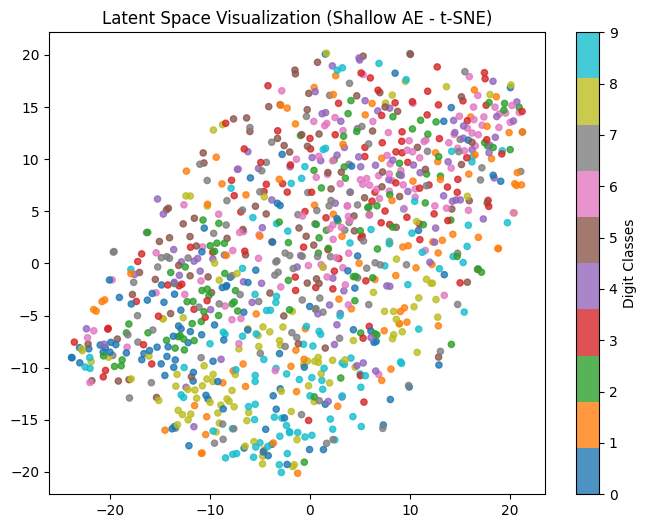

reconstruction...


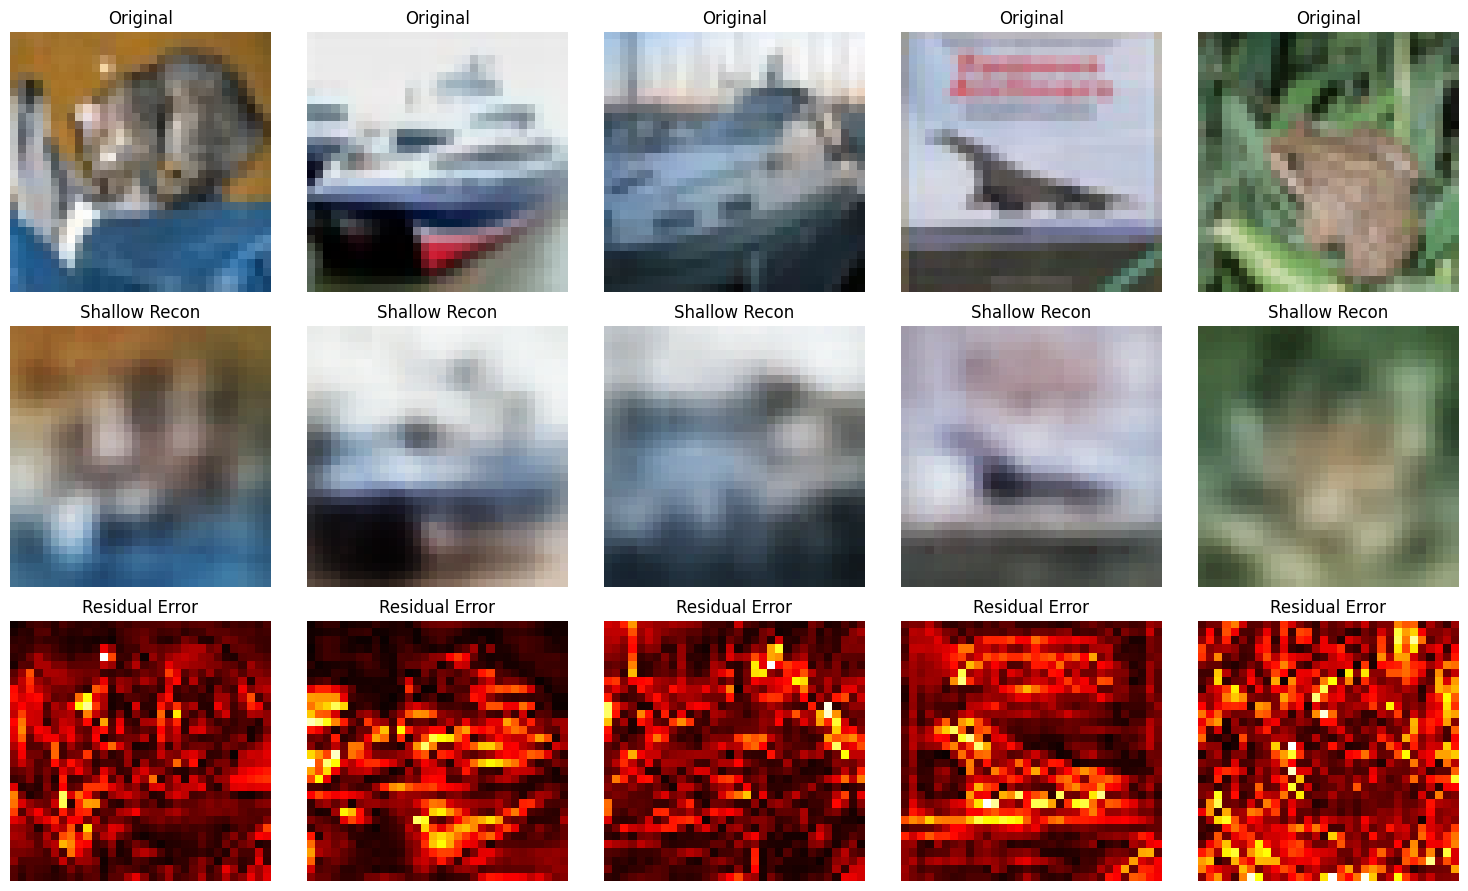

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

def visualize_shallow_results(model, loader, device, num_samples=1000):
    model.eval()
    zs, ys, imgs = [], [], []
    
    # 1. Feature extraction and images
    with torch.no_grad():
        for i, (img, lbl) in enumerate(loader):
            img = img.to(device)
            recon, z = model(img)
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
            if i == 0: # Only the first batch is used to display the reconstruction graph.
                original_imgs = img.cpu()
                recon_imgs = recon.cpu()
            if len(np.concatenate(zs)) >= num_samples:
                break
    
    Z = np.concatenate(zs)[:num_samples]
    Y = np.concatenate(ys)[:num_samples]

    # --- Plot A: t-SNE clustering diagram ---
    print("caculate t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    z_2d = tsne.fit_transform(Z)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=Y, cmap='tab10', alpha=0.8, s=20)
    plt.colorbar(scatter, ticks=range(10), label='Digit Classes')
    plt.title("Latent Space Visualization (Shallow AE - t-SNE)")
    plt.savefig("shallow_tsne.png", dpi=300)
    plt.show()

    # --- Drawing B: Comparison of Reconstruction Diagram and Residual Diagram ---
    print("reconstruction...")
    n_show = 5
    fig, axes = plt.subplots(3, n_show, figsize=(15, 9))
    for i in range(n_show):
        # origin
        axes[0, i].imshow(original_imgs[i].permute(1, 2, 0) * 0.5 + 0.5)
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')
        # reconstruction
        axes[1, i].imshow(recon_imgs[i].permute(1, 2, 0) * 0.5 + 0.5)
        axes[1, i].set_title("Shallow Recon")
        axes[1, i].axis('off')
        # heat map
        diff = torch.abs(original_imgs[i] - recon_imgs[i]).mean(dim=0)
        im = axes[2, i].imshow(diff, cmap='hot')
        axes[2, i].set_title("Residual Error")
        axes[2, i].axis('off')
    
    plt.tight_layout()
    plt.savefig("shallow_reconstruction.png", dpi=300)
    plt.show()


visualize_shallow_results(model, test_loader, device)

Starting Training on CIFAR-10 with cpu...
Epoch [1/10], MSE Loss: 0.1219
Epoch [2/10], MSE Loss: 0.0730
Epoch [3/10], MSE Loss: 0.0628
Epoch [4/10], MSE Loss: 0.0578
Epoch [5/10], MSE Loss: 0.0547
Epoch [6/10], MSE Loss: 0.0515
Epoch [7/10], MSE Loss: 0.0503
Epoch [8/10], MSE Loss: 0.0494
Epoch [9/10], MSE Loss: 0.0487
Epoch [10/10], MSE Loss: 0.0482

Executing SPCA Selection & Linear Probing...
SPCA Components: 8 -> Accuracy: 0.2652
SPCA Components: 16 -> Accuracy: 0.3143


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SPCA Components: 32 -> Accuracy: 0.3556
SPCA Components: 64 -> Accuracy: 0.3965


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SPCA Components: 128 -> Accuracy: 0.4347


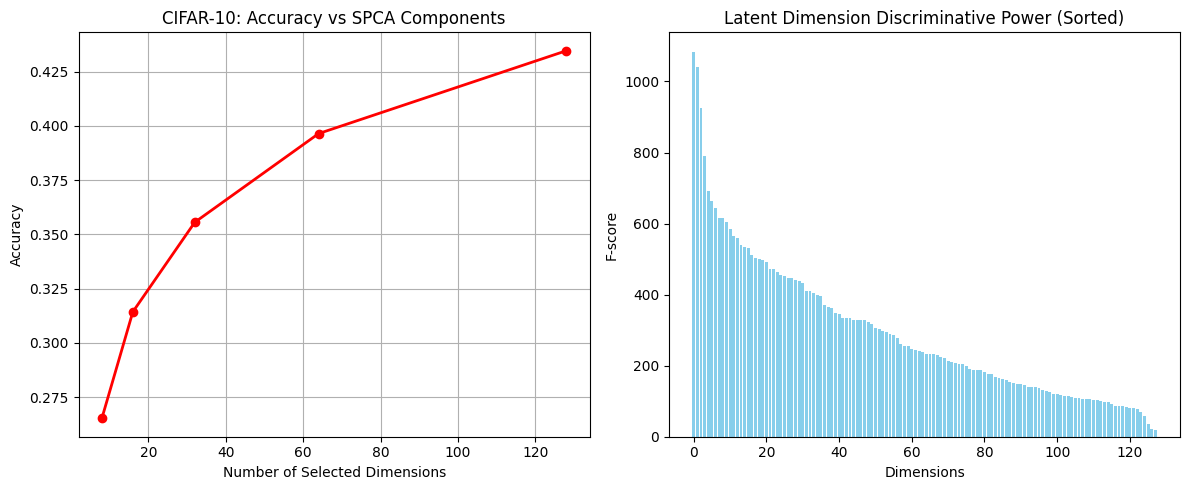

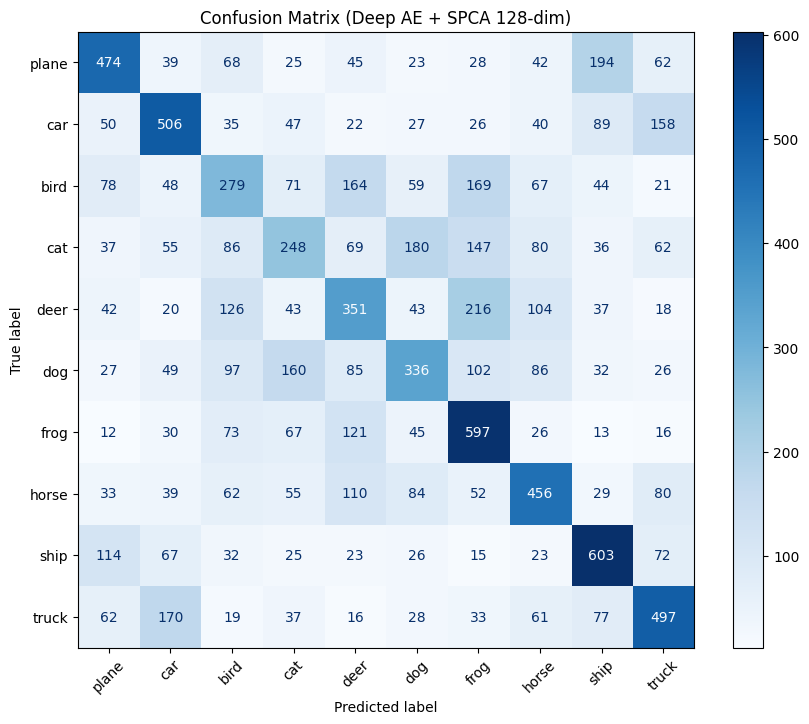

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
initial_latent_dim = 128  
max_epochs = 10         

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10('./data', train=False, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# --- 2.  (Deep CIFAR AE) ---
class Deep_CIFAR_AE_Adjusted(nn.Module):
    def __init__(self, latent_dim=128):
        super(Deep_CIFAR_AE_Adjusted, self).__init__()
        
        # Encoder: Increase convolution depth but limit pooling iterations to achieve an 8x8 final output.
        self.encoder_conv = nn.Sequential(
            #  32x32 -> 16x16
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2), 
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.MaxPool2d(2), 
            
            #  16x16 -> 8x8
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2), 
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.MaxPool2d(2), 
            
            #  8x8 (No more downsampling, but increase the depth of non-linear feature extraction)
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2)
        )
        
        # The flattened size is 256 * 8 * 8
        self.encoder_fc = nn.Sequential(
            nn.Linear(256 * 8 * 8, 512), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, latent_dim)
        )
        
        # Decoder: Restore from latent_dim to 256 * 8 * 8
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 512), nn.ReLU(),
            nn.Linear(512, 256 * 8 * 8), nn.ReLU()
        )
        
        #Deconvolutional layer: restored from 8x8 to 32x32
        self.decoder_conv = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.BatchNorm2d(64), nn.ReLU(), # 8x8 -> 16x16
            nn.ConvTranspose2d(64, 3, 2, stride=2), nn.Tanh() # 16x16 -> 32x32
        )

    def forward(self, x):
        conv_out = self.encoder_conv(x)
        # At this point, the shape of conv_out is (batch_size, 256, 8, 8)
        z = conv_out.view(x.size(0), -1)
        z_latent = self.encoder_fc(z)
        
        d = self.decoder_fc(z_latent).view(-1, 256, 8, 8)
        x_hat = self.decoder_conv(d)
        return x_hat, z_latent

# --- 3. train ---
model = Deep_CIFAR_AE_Adjusted(latent_dim=initial_latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Starting Training on CIFAR-10 with {device}...")
for epoch in range(max_epochs):
    model.train()
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        x_hat, _ = model(imgs)
        loss = nn.MSELoss()(x_hat, imgs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"Epoch [{epoch+1}/{max_epochs}], MSE Loss: {total_loss/len(train_loader):.4f}")

# --- 4. Feature extraction and SPCA screening ---
def extract_features(loader):
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for img, lbl in loader:
            _, z = model(img.to(device))
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
    return np.vstack(zs), np.hstack(ys)

Z_train, Y_train = extract_features(train_loader)
Z_test, Y_test = extract_features(test_loader)

# Evaluate dimension sequence
dims = [8, 16, 32, 64, 128]
accuracies = []

print("\nExecuting SPCA Selection & Linear Probing...")
for d in dims:
    selector = SelectKBest(score_func=f_classif, k=d)
    Z_train_sel = selector.fit_transform(Z_train, Y_train)
    Z_test_sel = selector.transform(Z_test)
    
    # The number of iterations was increased because the CIFAR feature surface is more complex.
    clf = LogisticRegression(max_iter=2000, solver='lbfgs').fit(Z_train_sel, Y_train)
    acc = clf.score(Z_test_sel, Y_test)
    accuracies.append(acc)
    print(f"SPCA Components: {d} -> Accuracy: {acc:.4f}")


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(dims, accuracies, 'o-r', linewidth=2)
plt.title("CIFAR-10: Accuracy vs SPCA Components")
plt.xlabel("Number of Selected Dimensions")
plt.ylabel("Accuracy")
plt.grid(True)

# (F-scores)
f_vals, _ = f_classif(Z_train, Y_train)
plt.subplot(1, 2, 2)
plt.bar(range(initial_latent_dim), np.sort(f_vals)[::-1], color='skyblue')
plt.title("Latent Dimension Discriminative Power (Sorted)")
plt.xlabel("Dimensions")
plt.ylabel("F-score")
plt.tight_layout()
plt.show()

# Confusion matrix
y_pred = clf.predict(Z_test_sel) 
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(Y_test, y_pred, display_labels=classes, cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix (Deep AE + SPCA 128-dim)")
plt.show()

caculate t-SNE...


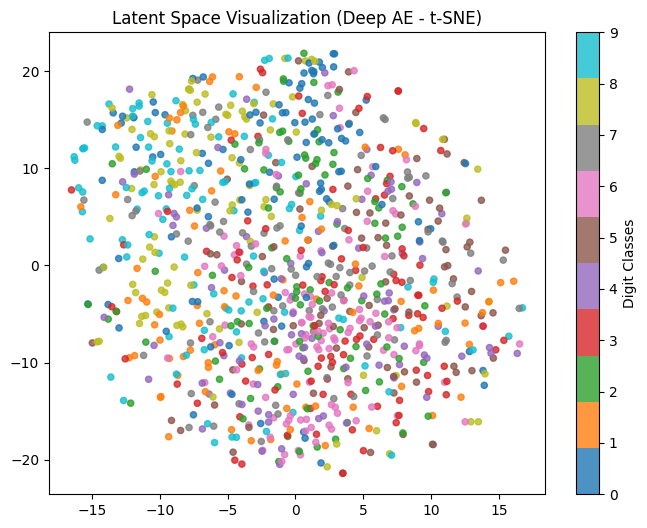

reconstruction...


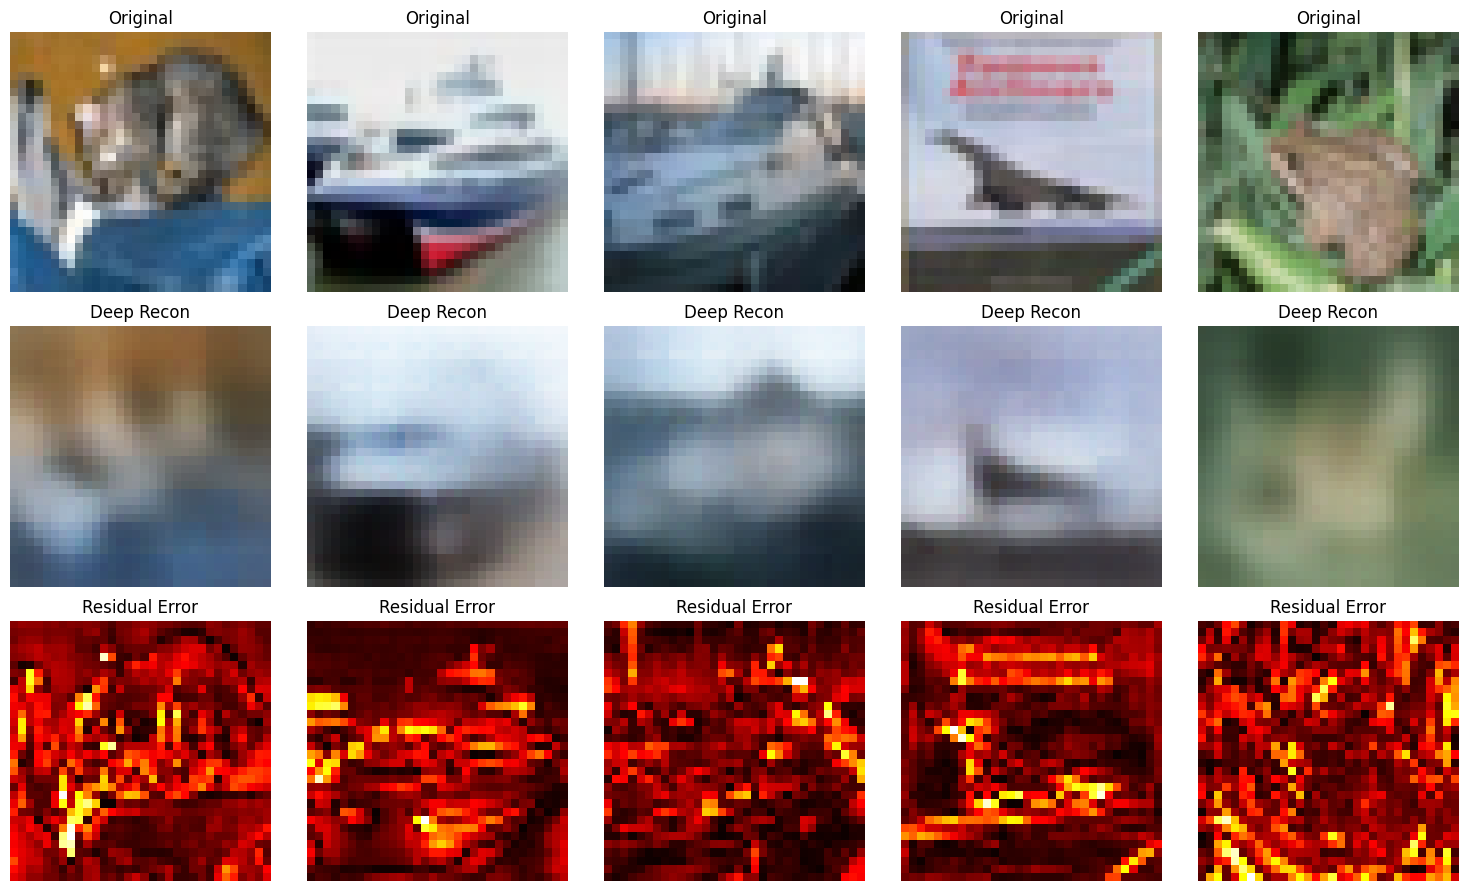

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

def visualize_shallow_results(model, loader, device, num_samples=1000):
    model.eval()
    zs, ys, imgs = [], [], []
    
    # 1. Feature extraction and images
    with torch.no_grad():
        for i, (img, lbl) in enumerate(loader):
            img = img.to(device)
            recon, z = model(img)
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
            if i == 0: 
                original_imgs = img.cpu()
                recon_imgs = recon.cpu()
            if len(np.concatenate(zs)) >= num_samples:
                break
    
    Z = np.concatenate(zs)[:num_samples]
    Y = np.concatenate(ys)[:num_samples]


    print("caculate t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    z_2d = tsne.fit_transform(Z)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=Y, cmap='tab10', alpha=0.8, s=20)
    plt.colorbar(scatter, ticks=range(10), label='Digit Classes')
    plt.title("Latent Space Visualization (Deep AE - t-SNE)")
    plt.savefig("Deep_tsne.png", dpi=300)
    plt.show()


    print("reconstruction...")
    n_show = 5
    fig, axes = plt.subplots(3, n_show, figsize=(15, 9))
    for i in range(n_show):
        # Origin
        axes[0, i].imshow(original_imgs[i].permute(1, 2, 0) * 0.5 + 0.5)
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')
        # reconstruction
        axes[1, i].imshow(recon_imgs[i].permute(1, 2, 0) * 0.5 + 0.5)
        axes[1, i].set_title("Deep Recon")
        axes[1, i].axis('off')
        # heatmap
        diff = torch.abs(original_imgs[i] - recon_imgs[i]).mean(dim=0)
        im = axes[2, i].imshow(diff, cmap='hot')
        axes[2, i].set_title("Residual Error")
        axes[2, i].axis('off')
    
    plt.tight_layout()
    plt.savefig("Deep_reconstruction.png", dpi=300)
    plt.show()

visualize_shallow_results(model, test_loader, device)


Training SAE with MSE Weight (Alpha) = 1.0...

Training SAE with MSE Weight (Alpha) = 0.5...

Training SAE with MSE Weight (Alpha) = 0.1...

Training SAE with MSE Weight (Alpha) = 0.01...


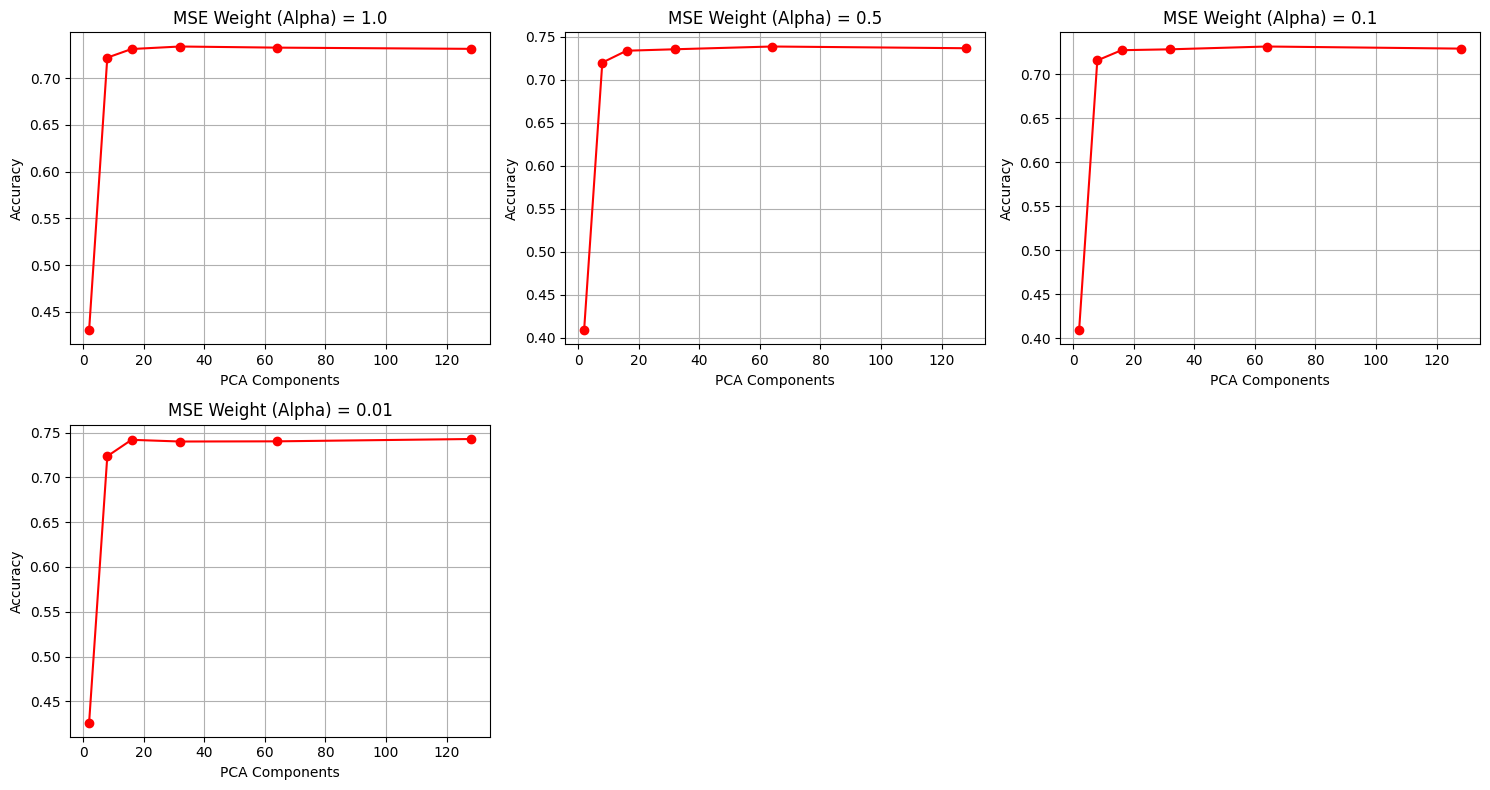

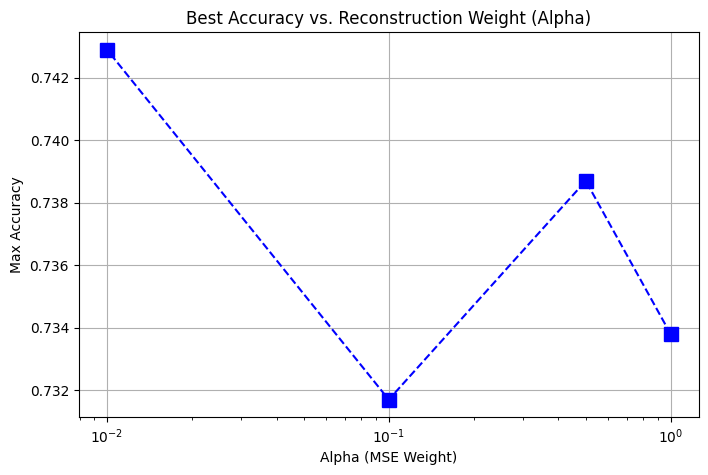

In [ ]:
#loss function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 1. Configuration and Dataset ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs_sae = 7 
initial_latent_dim = 128 
# Set the range of variation for the reconstruction weights (Alpha).

alpha_list = [1.0, 0.5, 0.1, 0.01] 
pca_dims = [2, 8, 16, 32, 64, 128]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_loader = DataLoader(torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(torchvision.datasets.CIFAR10('./data', train=False, transform=transform), batch_size=batch_size, shuffle=False)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# --- 2. model ---
class CIFAR10_SAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(CIFAR10_SAE, self).__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_enc = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512), nn.ReLU(),
            nn.Linear(512, latent_dim)
        )
        self.classifier = nn.Linear(latent_dim, 10)
        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim, 512), nn.ReLU(),
            nn.Linear(512, 64 * 8 * 8)
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder_conv(x).view(x.size(0), -1)
        z_latent = self.fc_enc(z)
        y_hat = self.classifier(z_latent)
        d = self.fc_dec(z_latent).view(-1, 64, 8, 8)
        x_hat = self.decoder_conv(d)
        return x_hat, y_hat, z_latent

def extract_features(model, loader):
    model.eval()
    zs, ys, raw_imgs = [], [], []
    with torch.no_grad():
        for img, lbl in loader:
            _, _, z = model(img.to(device))
            zs.append(z.cpu().numpy())
            ys.append(lbl.numpy())
            raw_imgs.append(img.numpy())
    return np.vstack(zs), np.hstack(ys), np.vstack(raw_imgs)

# --- 3. Sensitivity cycle experiment ---
all_results = {}
best_accs = []
visual_data = {}
confusion_matrices = {}

for alpha in alpha_list:
    print(f"\nTraining SAE with MSE Weight (Alpha) = {alpha}...")
    model = CIFAR10_SAE(latent_dim=initial_latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs_sae):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            x_hat, y_hat, _ = model(imgs)
            # core formula: Classification weight is 1, reconstruction weight is alpha.
            loss = nn.CrossEntropyLoss()(y_hat, lbls) + alpha * F.mse_loss(x_hat, imgs)
            loss.backward(); optimizer.step()
    
    Z_train, Y_train, _ = extract_features(model, train_loader)
    Z_test, Y_test, X_test_raw = extract_features(model, test_loader)
    
    acc_list = []
    last_preds = None
    
    for d in pca_dims:
        pca = PCA(n_components=d)
        Z_train_pca = pca.fit_transform(Z_train)
        Z_test_pca = pca.transform(Z_test)
        clf = LogisticRegression(max_iter=500).fit(Z_train_pca, Y_train)
        acc = clf.score(Z_test_pca, Y_test)
        acc_list.append(acc)
        if d == 128: # 记录最Record the confusion matrix in the highest dimension维度下的混淆矩阵
            last_preds = clf.predict(Z_test_pca)
    
    all_results[alpha] = acc_list
    best_accs.append(max(acc_list))
    
    confusion_matrices[alpha] = confusion_matrix(Y_test, last_preds)
    
    idx = 10 
    test_img = torch.tensor(X_test_raw[idx:idx+1]).to(device)
    with torch.no_grad():
        recon_img, _, _ = model(test_img)
    visual_data[alpha] = (X_test_raw[idx], recon_img.cpu().numpy()[0])



# 4.1 PCA accuracy curve at each alpha
plt.figure(figsize=(15, 8))
for i, alpha in enumerate(alpha_list):
    plt.subplot(2, 3, i+1)
    plt.plot(pca_dims, all_results[alpha], 'o-r')
    plt.title(f"MSE Weight (Alpha) = {alpha}")
    plt.xlabel("PCA Components")
    plt.ylabel("Accuracy")
    plt.grid(True)
plt.tight_layout()
plt.show()

# 4.2 Summary chart: Best accuracy as a function of Alpha
plt.figure(figsize=(8, 5))
plt.plot(alpha_list, best_accs, 's--b', markersize=10)
plt.xscale('log')
plt.title("Best Accuracy vs. Reconstruction Weight (Alpha)")
plt.xlabel("Alpha (MSE Weight)")
plt.ylabel("Max Accuracy")
plt.grid(True)
plt.show()



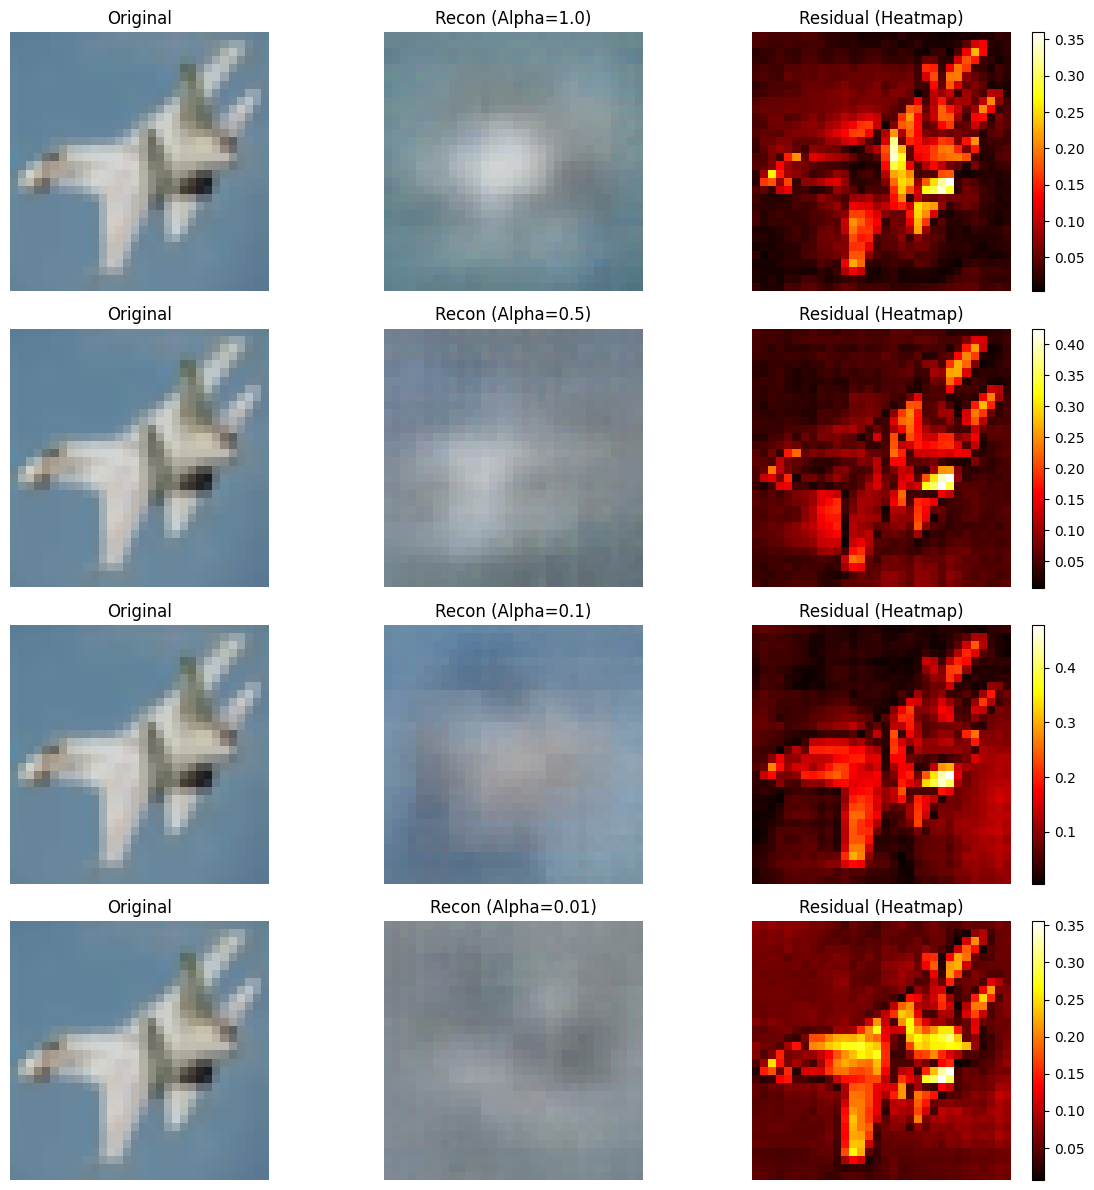

In [ ]:
display_alphas = [1.0, 0.5, 0.1, 0.01]
fig, axes = plt.subplots(len(display_alphas), 3, figsize=(12, 3 * len(display_alphas)))

for i, alpha in enumerate(display_alphas):
    orig, recon = visual_data[alpha]
    # Anti-normalization
    o_img = np.transpose(orig, (1, 2, 0)) * 0.5 + 0.5
    r_img = np.transpose(recon, (1, 2, 0)) * 0.5 + 0.5
    o_img, r_img = np.clip(o_img, 0, 1), np.clip(r_img, 0, 1)
    
    # Calculate the residual heatmap
    residual = np.mean(np.abs(o_img - r_img), axis=2)
    
    axes[i, 0].imshow(o_img); axes[i, 0].set_title(f"Original"); axes[i, 0].axis('off')
    axes[i, 1].imshow(r_img); axes[i, 1].set_title(f"Recon (Alpha={alpha})"); axes[i, 1].axis('off')
    im = axes[i, 2].imshow(residual, cmap='hot'); axes[i, 2].set_title("Residual (Heatmap)"); axes[i, 2].axis('off')
    plt.colorbar(im, ax=axes[i, 2])

plt.tight_layout()
plt.show()

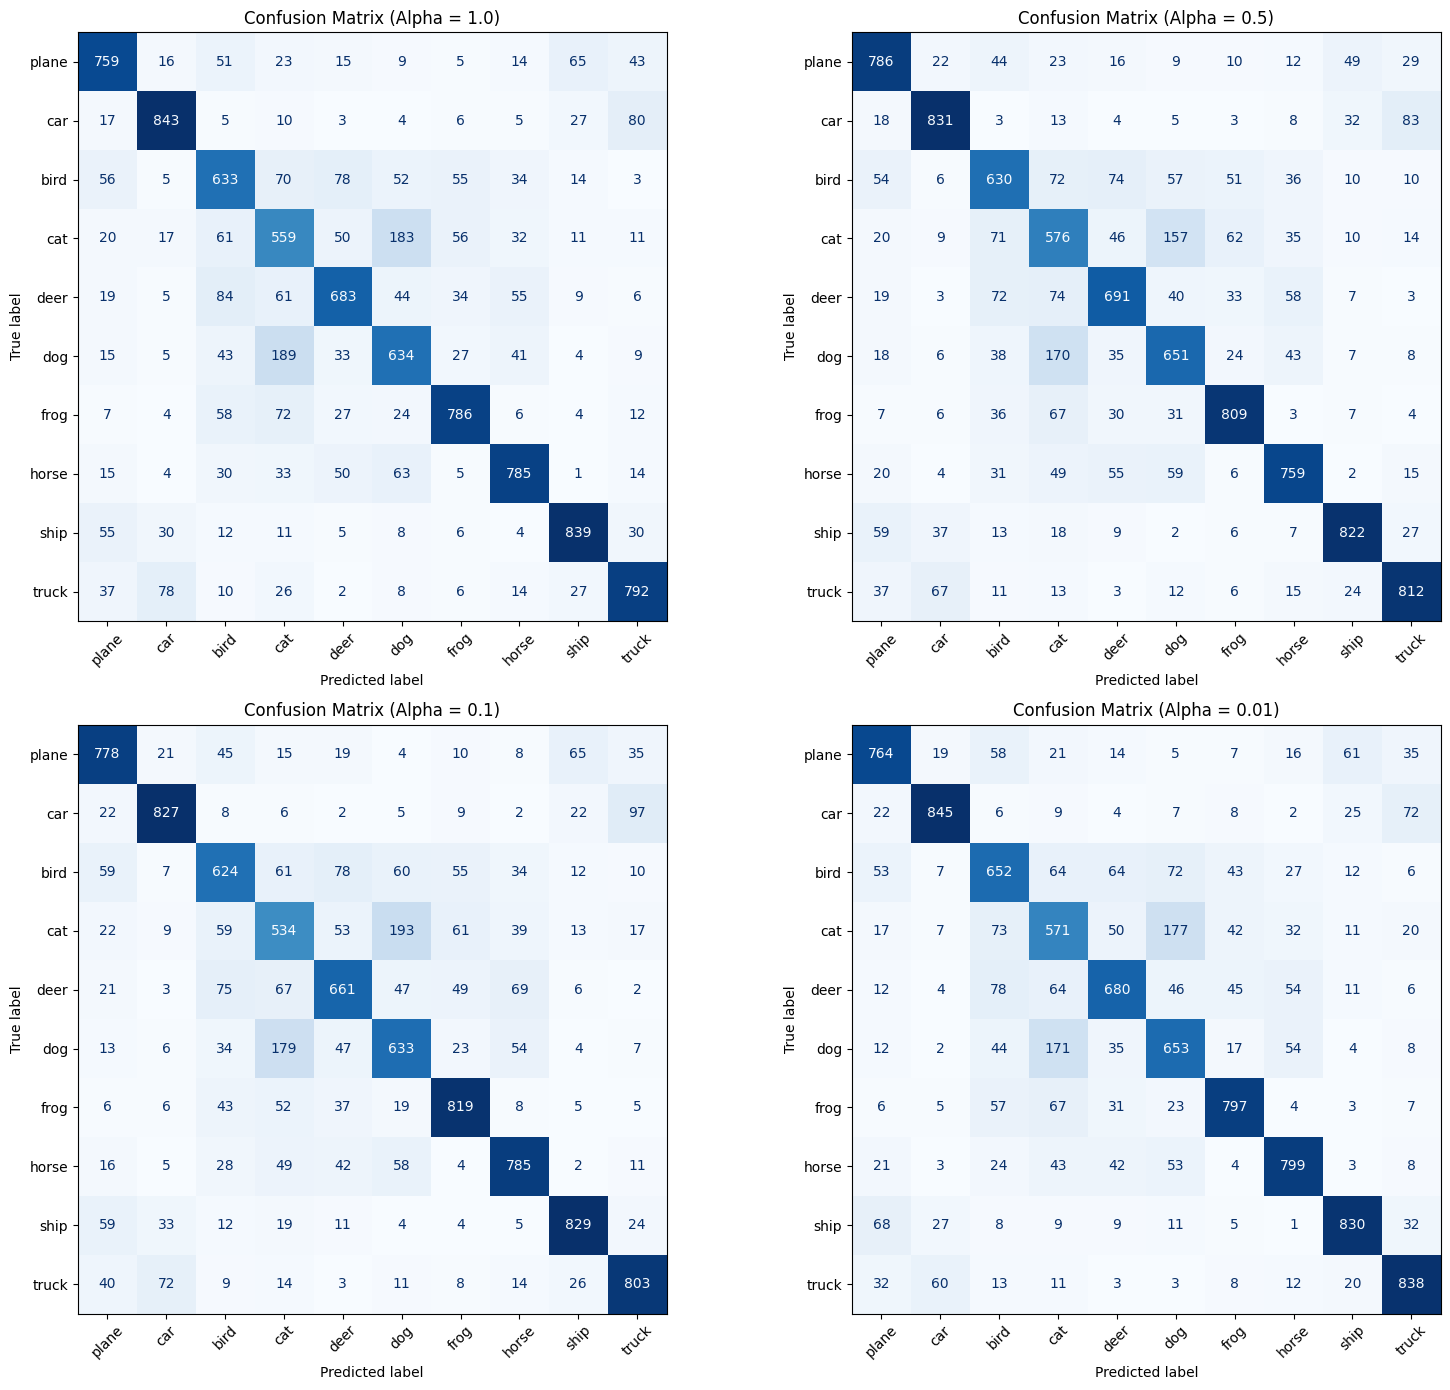


--- Per-Class Accuracy Analysis ---
Class       α=1.0     α=0.5     α=0.1     α=0.01    
----------------------------------------------------
plane       0.7590  0.7860  0.7780  0.7640  
car         0.8430  0.8310  0.8270  0.8450  
bird        0.6330  0.6300  0.6240  0.6520  
cat         0.5590  0.5760  0.5340  0.5710  
deer        0.6830  0.6910  0.6610  0.6800  
dog         0.6340  0.6510  0.6330  0.6530  
frog        0.7860  0.8090  0.8190  0.7970  
horse       0.7850  0.7590  0.7850  0.7990  
ship        0.8390  0.8220  0.8290  0.8300  
truck       0.7920  0.8120  0.8030  0.8380  


In [ ]:

# --- 6. Confusion Matrix Comparison Display ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for i, alpha in enumerate(alpha_list):
    cm = confusion_matrices[alpha]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[i], cmap='Blues', xticks_rotation=45, colorbar=False)
    axes[i].set_title(f"Confusion Matrix (Alpha = {alpha})")

plt.tight_layout()
plt.show()

# Print the accuracy comparison table for each category. 
print("\n--- Per-Class Accuracy Analysis ---")
header = f"{'Class':<12}" + "".join([f"α={a:<8}" for a in alpha_list])
print(header)
print("-" * len(header))

for i, cls_name in enumerate(classes):
    row = f"{cls_name:<12}"
    for alpha in alpha_list:
        cm = confusion_matrices[alpha]
        acc = cm[i, i] / cm[i, :].sum()
        row += f"{acc:.4f}  "
    print(row)

Extracting clean features for baseline classifier...
Noise Level 0.00 -> Accuracy: 0.4620
Noise Level 0.10 -> Accuracy: 0.4570
Noise Level 0.30 -> Accuracy: 0.4335
Noise Level 0.50 -> Accuracy: 0.3918


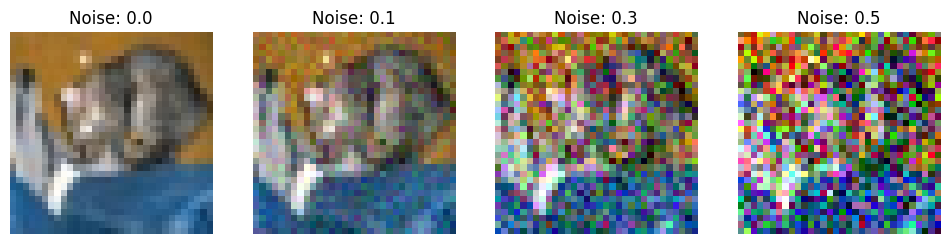

In [ ]:
#Effects of Gaussian noise on shallow models
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif

# --- 1. Define a function to add Gaussian noise. ---
def add_gaussian_noise(imgs, noise_factor=0.2):
    
    noise = torch.randn_like(imgs) * noise_factor
    noisy_imgs = imgs + noise
    # Limited to the normalization range [-1, 1]
    return torch.clamp(noisy_imgs, -1.0, 1.0)

# --- 2. Evaluation function: Extracting and testing features under different noise intensities ACC ---
def run_robustness_test(model, train_loader, test_loader, noise_levels=[0.0, 0.1, 0.3, 0.5]):
    model.eval()
    
    # A. First, train the basic classifier in a noise-free environment. (Baseline)
    print("Extracting clean features for baseline classifier...")
    zs_train, ys_train = [], []
    with torch.no_grad():
        for imgs, lbls in train_loader:
            _, z = model(imgs.to(device))
            zs_train.append(z.cpu().numpy())
            ys_train.append(lbls.numpy())
    
    Z_train = np.vstack(zs_train)
    Y_train = np.hstack(ys_train)
    
    # train Logistic Regression 
    selector = SelectKBest(score_func=f_classif, k=128)
    Z_train_sel = selector.fit_transform(Z_train, Y_train)
    clf = LogisticRegression(max_iter=1000).fit(Z_train_sel, Y_train)
    
    # B. Testing classification accuracy under different noise levels
    noise_results = []
    sample_images = {} 
    
    for level in noise_levels:
        zs_test, ys_test = [], []
        with torch.no_grad():
            for i, (imgs, lbls) in enumerate(test_loader):
                # Core step: Injecting noise
                noisy_imgs = add_gaussian_noise(imgs, noise_factor=level).to(device)
                _, z = model(noisy_imgs)
                
                zs_test.append(z.cpu().numpy())
                ys_test.append(lbls.numpy())
                
                
                if i == 0:
                    sample_images[level] = noisy_imgs[0].cpu()

        Z_test = np.vstack(zs_test)
        Y_test = np.hstack(ys_test)
        Z_test_sel = selector.transform(Z_test)
        
        acc = clf.score(Z_test_sel, Y_test)
        noise_results.append(acc)
        print(f"Noise Level {level:.2f} -> Accuracy: {acc:.4f}")
        
    return noise_levels, noise_results, sample_images

# ---  ---
levels, accs, noisy_samples = run_robustness_test(model, train_loader, test_loader)

# --- 4. Visualize the impact of noise on images (Figure X) ---
plt.figure(figsize=(12, 3))
for i, level in enumerate(levels):
    plt.subplot(1, len(levels), i+1)
    # Inverse normalization display
    img_display = noisy_samples[level].permute(1, 2, 0).numpy() * 0.5 + 0.5
    plt.imshow(np.clip(img_display, 0, 1))
    plt.title(f"Noise: {level}")
    plt.axis('off')
plt.show()

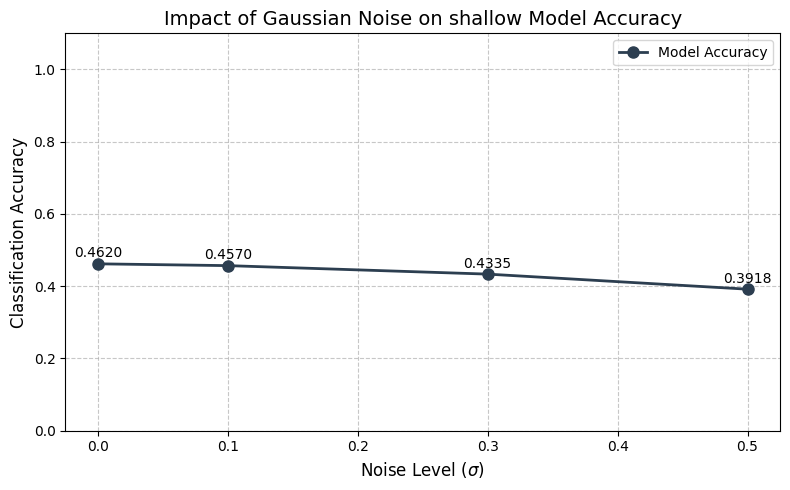

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(levels, accs, marker='o', linestyle='-', linewidth=2, markersize=8, color='#2c3e50', label='Model Accuracy')

# Add numerical labels
for i, acc in enumerate(accs):
    plt.text(levels[i], acc + 0.01, f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

# Format the chart
plt.title('Impact of Gaussian Noise on shallow Model Accuracy', fontsize=14)
plt.xlabel('Noise Level ($\sigma$)', fontsize=12)
plt.ylabel('Classification Accuracy', fontsize=12)
plt.ylim(0, 1.1)  # The accuracy range is between 0 and 1; leave some space for writing numbers.
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


plt.tight_layout()
plt.show()

Extracting clean features for baseline classifier...


c:\Users\Knuse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Noise Level 0.00 -> Accuracy: 0.4367
Noise Level 0.10 -> Accuracy: 0.4348
Noise Level 0.30 -> Accuracy: 0.4308
Noise Level 0.50 -> Accuracy: 0.4173


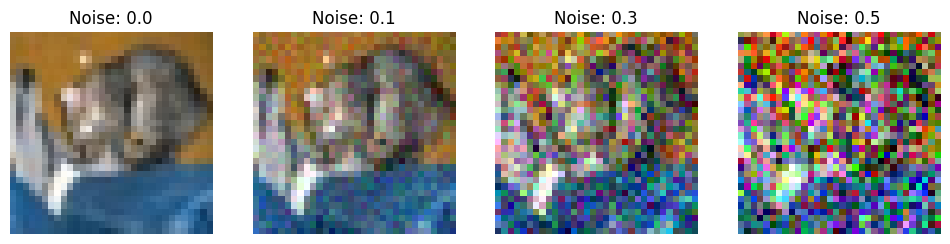

In [ ]:
#The impact of Gaussian noise on deep models
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif


def add_gaussian_noise(imgs, noise_factor=0.2):
    
    noise = torch.randn_like(imgs) * noise_factor
    noisy_imgs = imgs + noise

    return torch.clamp(noisy_imgs, -1.0, 1.0)


def run_robustness_test(model, train_loader, test_loader, noise_levels=[0.0, 0.1, 0.3, 0.5]):
    model.eval()
    
    
    print("Extracting clean features for baseline classifier...")
    zs_train, ys_train = [], []
    with torch.no_grad():
        for imgs, lbls in train_loader:
            _, z = model(imgs.to(device))
            zs_train.append(z.cpu().numpy())
            ys_train.append(lbls.numpy())
    
    Z_train = np.vstack(zs_train)
    Y_train = np.hstack(ys_train)
    
    
    selector = SelectKBest(score_func=f_classif, k=128)
    Z_train_sel = selector.fit_transform(Z_train, Y_train)
    clf = LogisticRegression(max_iter=1000).fit(Z_train_sel, Y_train)
    
    noise_results = []
    sample_images = {} 
    
    for level in noise_levels:
        zs_test, ys_test = [], []
        with torch.no_grad():
            for i, (imgs, lbls) in enumerate(test_loader):
                noisy_imgs = add_gaussian_noise(imgs, noise_factor=level).to(device)
                _, z = model(noisy_imgs)
                
                zs_test.append(z.cpu().numpy())
                ys_test.append(lbls.numpy())
                
                
                if i == 0:
                    sample_images[level] = noisy_imgs[0].cpu()

        Z_test = np.vstack(zs_test)
        Y_test = np.hstack(ys_test)
        Z_test_sel = selector.transform(Z_test)
        
        acc = clf.score(Z_test_sel, Y_test)
        noise_results.append(acc)
        print(f"Noise Level {level:.2f} -> Accuracy: {acc:.4f}")
        
    return noise_levels, noise_results, sample_images


levels, accs, noisy_samples = run_robustness_test(model, train_loader, test_loader)


plt.figure(figsize=(12, 3))
for i, level in enumerate(levels):
    plt.subplot(1, len(levels), i+1)
    
    img_display = noisy_samples[level].permute(1, 2, 0).numpy() * 0.5 + 0.5
    plt.imshow(np.clip(img_display, 0, 1))
    plt.title(f"Noise: {level}")
    plt.axis('off')
plt.show()

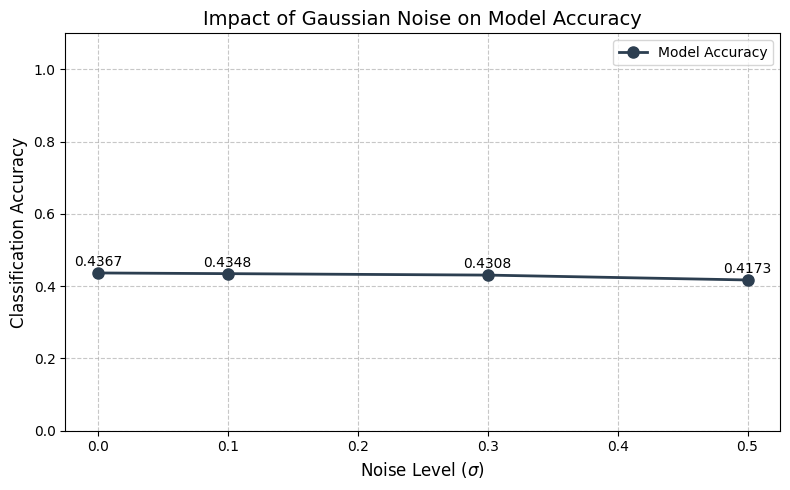

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(levels, accs, marker='o', linestyle='-', linewidth=2, markersize=8, color='#2c3e50', label='Model Accuracy')


for i, acc in enumerate(accs):
    plt.text(levels[i], acc + 0.01, f'{acc:.4f}', ha='center', va='bottom', fontsize=10)


plt.title('Impact of Gaussian Noise on Model Accuracy', fontsize=14)
plt.xlabel('Noise Level ($\sigma$)', fontsize=12)
plt.ylabel('Classification Accuracy', fontsize=12)
plt.ylim(0, 1.1) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


plt.tight_layout()
plt.show()